In [1]:
# ============================================================
# CELL 1 (ПАТЧ): Еталон + PARQUET_BAGS
# Зміни відносно оригіналу:
#   1. Додано CFG["parquet_path"] і CFG["parquet_emb_key"]
#   2. Завантажуємо PARQUET_BAGS після symlinks
#   3. SlideEmbDataset.__getitem__ конкатенує parquet-патчі
#   4. Додано діагностику: скільки слайдів збагачено
# Все інше — без змін (split, фільтрація, D_EMB, etc.)
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

CFG = {
    "seed": 42,
    "val_size": 0.2,

    "emb_dirs": [
        "/kaggle/input/datasets/bohatyrenkovictor/uni2h-cam16-cam17-nice-embeddings-part1/embeddings_uni2h_cam16_cam17_pool512_part1_fixed",
        "/kaggle/input/datasets/bohatyrenkovictor/uni2h-cam16-cam17-nice-embeddings-part2/embeddings_uni2h_cam16_cam17_pool512_part2_fixed",
        "/kaggle/input/datasets/bohatyrenkovictor/uni2h-cam16-cam17-nice-embeddings-part3/embeddings_uni2h_cam16_cam17_pool512_part3_fixed",
    ],
    "emb_dir": "/kaggle/working/emb_all",

    "labels_csv_path": (
        "/kaggle/input/datasets/vladimirsydor/camelyon-16-17/"
        "annotation_meta/annotation_meta/CAMELYON17/training/stage_labels.csv"
    ),
    "cam16_pseudo_csv": (
        "/kaggle/input/datasets/bohatyrenkovictor/psedolabelscsv/"
        "cam16_stage_pseudolabels.csv"
    ),

    # ✅ НОВЕ: шлях до parquet з hard-mined патчами
    "parquet_path": "/kaggle/input/datasets/bohatyrenkovictor/minedpatches/data.parquet",
    # ключ колонки з ембедінгами в parquet (зазвичай "emb" або "features")
    "parquet_emb_key": "emb",

    "hid":              256,
    "dropout":          0.25,
    "mil_lr":           2e-4,
    "mil_weight_decay": 1e-4,
    "mil_epochs":       20,
    "warmup_epochs":    2,
    "grad_clip":        5.0,
    "early_patience":   6,
    "num_workers":      2,

    "K_TRAIN":              1024,
    "mining_start_epoch":   2,
    "mining_mode":          "semi-hard",
    "mining_random_frac":   0.2,
    "mining_pool_top_mult": 3.0,

    "missing_pt_report_n": 30,
}

np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
torch.cuda.manual_seed_all(CFG["seed"])

STAGE2ID = {"negative": 0, "itc": 1, "micro": 2, "macro": 3}
ID2STAGE  = {v: k for k, v in STAGE2ID.items()}

# ================================================================
# КРОК 1: Symlinks (без змін)
# ================================================================
os.makedirs(CFG["emb_dir"], exist_ok=True)

all_pt_files = []
for d in CFG["emb_dirs"]:
    if os.path.isdir(d):
        found = glob.glob(os.path.join(d, "**", "*.pt"), recursive=True)
        all_pt_files.extend(found)
        print(f"  {os.path.basename(d)}: знайдено {len(found)} .pt файлів")
    else:
        print(f"  ⚠️  Не знайдено директорію: {d}")

print(f"Всього .pt файлів: {len(all_pt_files)}")

created = skipped = conflicts = 0
for src in all_pt_files:
    fname = os.path.basename(src)
    dst   = os.path.join(CFG["emb_dir"], fname)
    if not os.path.exists(dst):
        os.symlink(src, dst)
        created += 1
    else:
        existing_src = os.readlink(dst) if os.path.islink(dst) else dst
        if os.path.realpath(existing_src) != os.path.realpath(src):
            conflicts += 1
        else:
            skipped += 1

print(f"Symlinks: створено={created}, пропущено={skipped}, конфліктів={conflicts}")

available_uids = {
    fname[:-3]
    for fname in os.listdir(CFG["emb_dir"])
    if fname.endswith(".pt")
}
print(f"\nДоступно slide_uid: {len(available_uids)}")
n_cam17 = sum(1 for u in available_uids if u.startswith("c17__"))
n_cam16 = sum(1 for u in available_uids if u.startswith("c16__"))
print(f"  CAM17: {n_cam17} | CAM16: {n_cam16} | Інші: {len(available_uids) - n_cam17 - n_cam16}")

# ================================================================
# ✅ КРОК 1.5: Завантаження PARQUET_BAGS (нове)
#
# Логіка:
#   - читаємо parquet один раз у пам'ять
#   - нормалізуємо slide_uid так само як і в .pt
#   - перевіряємо розмірність D_EMB ПІСЛЯ завантаження .pt
#     (тому dict будується тут, а перевірка розмірності — нижче)
# ================================================================
PARQUET_BAGS = {}  # slide_uid → Tensor[M, D]

if CFG.get("parquet_path") and os.path.exists(CFG["parquet_path"]):
    print(f"\nЗавантаження parquet: {CFG['parquet_path']}")
    pq = pd.read_parquet(CFG["parquet_path"])
    print(f"  Рядків у parquet: {len(pq)}")
    print(f"  Колонки: {list(pq.columns)}")

    def normalize_uid(x):
        s = str(x).lower()
        s = os.path.basename(s)
        s = s.replace(".tif", "").replace(".tiff", "")
        if s.startswith("c16__") or s.startswith("c17__"):
            return s
        if "patient" in s:
            return "c17__" + s
        return "c16__" + s

    emb_col = CFG["parquet_emb_key"]
    if emb_col not in pq.columns:
        # спробуємо знайти колонку автоматично
        emb_col = next(
            (c for c in pq.columns if pq[c].dtype == object and hasattr(pq[c].iloc[0], "__len__")),
            None
        )
        if emb_col is None:
            print("  ⚠️  Не знайдено колонку з ембедінгами в parquet — PARQUET_BAGS буде порожній")
        else:
            print(f"  Авто-знайдена колонка ембедінгів: '{emb_col}'")

    if emb_col:
        pq["slide_uid"] = pq["slide_id"].apply(normalize_uid)
        for uid, g in pq.groupby("slide_uid"):
            try:
                arr = np.stack(g[emb_col].values)
                PARQUET_BAGS[uid] = torch.tensor(arr, dtype=torch.float32)
            except Exception as e:
                print(f"  ⚠️  Пропускаємо {uid}: {e}")

    print(f"  PARQUET_BAGS: {len(PARQUET_BAGS)} слайдів")
    # Показуємо розмірності щоб виловити невідповідність заздалегідь
    dims = {uid: bag.shape[1] for uid, bag in PARQUET_BAGS.items()}
    unique_dims = set(dims.values())
    print(f"  Розмірності в PARQUET_BAGS: {unique_dims}")
else:
    print("\nParquet не вказано або файл відсутній — PARQUET_BAGS порожній")

# ================================================================
# КРОК 2: Labels (без змін)
# ================================================================
def load_cam17_labels(csv_path: str) -> pd.DataFrame:
    df   = pd.read_csv(csv_path)
    cols = [str(c).strip().lower() for c in df.columns]
    df.columns = cols

    stage_col = next(
        (c for c in df.columns
         if {"negative","itc","micro","macro"}.intersection(
             set(df[c].dropna().astype(str).str.lower().unique()))),
        None
    )
    tif_col = next(
        (c for c in df.columns
         if df[c].astype(str).str.contains(r"\.tiff?$", regex=True).any()),
        None
    )

    if stage_col and tif_col:
        out = df[[tif_col, stage_col]].copy()
        out["slide_id_raw"] = (
            out[tif_col].astype(str)
            .str.replace(r"\.tiff?$", "", regex=True)
            .str.strip()
        )
        out["slide_uid"]  = "c17__" + out["slide_id_raw"]
        out["stage"]      = out[stage_col].astype(str).str.lower().str.strip()
        out = out[out["stage"].isin(STAGE2ID)].copy()
        out["stage_id"]   = out["stage"].map(STAGE2ID).astype(int)
        out["patient_id"] = out["slide_id_raw"].str.extract(r"patient[_-]?(\d+)")[0].astype(float).astype("Int64")
        return out[["slide_uid","slide_id_raw","stage","stage_id","patient_id"]]

    raise ValueError(f"Не вдалося розпарсити CAM17 stage_labels.csv. Колонки: {list(df.columns)}")


def load_cam16_labels(csv_path: str) -> pd.DataFrame:
    df   = pd.read_csv(csv_path)
    cols = [str(c).strip().lower() for c in df.columns]
    df.columns = cols

    uid_col = next(
        (c for c in df.columns if any(k in c for k in ("slide","file","wsi","name","id"))),
        None
    )
    stage_col = next(
        (c for c in df.columns
         if {"negative","itc","micro","macro"}.intersection(
             set(df[c].dropna().astype(str).str.lower().unique()))),
        None
    )
    if uid_col is None or stage_col is None:
        raise ValueError(f"CAM16 CSV: не знайдено потрібні колонки. Є: {list(df.columns)}")

    def to_uid(x: str) -> str:
        s = os.path.basename(str(x)).strip()
        s = re.sub(r"\.tiff?$", "", s, flags=re.IGNORECASE).lower()
        return s if s.startswith("c16__") else "c16__" + s

    out              = df[[uid_col, stage_col]].copy()
    out["slide_uid"] = out[uid_col].map(to_uid)
    out["stage"]     = out[stage_col].astype(str).str.lower().str.strip()
    out = out[out["stage"].isin(STAGE2ID)].copy()
    out["stage_id"]   = out["stage"].map(STAGE2ID).astype(int)
    out["patient_id"] = -1
    out["dataset"]    = "cam16"
    return out[["slide_uid","stage","stage_id","patient_id","dataset"]].drop_duplicates("slide_uid").reset_index(drop=True)


# ================================================================
# КРОК 3: Split (без змін)
# ================================================================
def build_split(cam17_labels, cam16_labels, val_size=0.2, seed=42):
    rng     = np.random.RandomState(seed)
    cam17   = cam17_labels.copy()
    cam17["dataset"] = "cam17"

    patients = sorted(cam17["patient_id"].dropna().unique().tolist())
    n_val    = max(1, int(len(patients) * val_size))
    val_pts  = set(rng.choice(patients, size=n_val, replace=False).tolist())
    train_pts = set(patients) - val_pts

    cam17_train = cam17[cam17["patient_id"].isin(train_pts)].copy()
    cam17_val   = cam17[cam17["patient_id"].isin(val_pts)].copy()

    train_df = pd.concat([
        cam17_train[["slide_uid","stage","stage_id","patient_id","dataset"]],
        cam16_labels[["slide_uid","stage","stage_id","patient_id","dataset"]],
    ], ignore_index=True)
    val_df = cam17_val[["slide_uid","stage","stage_id","patient_id","dataset"]].copy()

    print(f"\n{'='*55}")
    print(f"Train: {len(train_df)} слайдів")
    print(train_df.groupby(["dataset","stage"]).size().to_string())
    print(f"\nVal (CAM17 only): {len(val_df)} слайдів")
    print(val_df["stage"].value_counts().to_string())
    print("="*55)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


def filter_to_available(df, uids, name):
    mask   = df["slide_uid"].isin(uids)
    n_miss = (~mask).sum()
    if n_miss:
        print(f"⚠️  {name}: {n_miss}/{len(df)} слайдів не мають .pt → відкидаємо")
        print(df.loc[~mask, "slide_uid"].head(10).tolist())
    kept = df[mask].reset_index(drop=True)
    print(f"✅ {name}: {len(kept)} слайдів з ембедінгами")
    return kept


cam17_labels = load_cam17_labels(CFG["labels_csv_path"])
print(f"CAM17 labels: {len(cam17_labels)} слайдів")

cam16_labels = load_cam16_labels(CFG["cam16_pseudo_csv"])
print(f"CAM16 labels: {len(cam16_labels)} слайдів")

train_df, val_df = build_split(cam17_labels, cam16_labels, CFG["val_size"], CFG["seed"])
train_df = filter_to_available(train_df, available_uids, "train_df")
val_df   = filter_to_available(val_df,   available_uids, "val_df")

# ================================================================
# КРОК 4: D_EMB + перевірка сумісності з parquet
# ================================================================
sample_uid = train_df["slide_uid"].iloc[0]
sample_pt  = os.path.join(CFG["emb_dir"], f"{sample_uid}.pt")

data  = torch.load(sample_pt, map_location="cpu")
emb   = data["features"].float()
D_EMB = emb.shape[1]

print(f"\nТест завантаження: {sample_uid}.pt  →  emb.shape={emb.shape}")

# ✅ Перевіряємо сумісність розмірностей parquet vs .pt
if PARQUET_BAGS:
    parquet_dims = {bag.shape[1] for bag in PARQUET_BAGS.values()}
    incompatible = parquet_dims - {D_EMB}
    if incompatible:
        print(f"\n⚠️  ПОПЕРЕДЖЕННЯ: parquet має розмірності {incompatible}, а .pt має {D_EMB}")
        print("   Патчі з несумісною розмірністю будуть МОВЧКИ ПРОПУЩЕНІ при конкатенації.")
        print("   Якщо це небажано — перероби parquet або .pt під одну розмірність.")
    else:
        n_enriched = sum(1 for uid in train_df["slide_uid"] if uid in PARQUET_BAGS)
        n_enriched_val = sum(1 for uid in val_df["slide_uid"] if uid in PARQUET_BAGS)
        print(f"\n✅ Parquet сумісний (D={D_EMB})")
        print(f"   Train слайдів зі збагаченням: {n_enriched}/{len(train_df)}")
        print(f"   Val   слайдів зі збагаченням: {n_enriched_val}/{len(val_df)}")
        # Середня кількість додаткових патчів
        extra_counts = [PARQUET_BAGS[uid].shape[0] for uid in train_df["slide_uid"] if uid in PARQUET_BAGS]
        if extra_counts:
            print(f"   Середньо патчів з parquet на слайд: {np.mean(extra_counts):.0f} "
                  f"(min={min(extra_counts)}, max={max(extra_counts)})")

# ================================================================
# КРОК 5: SlideEmbDataset з parquet-інʼєкцією
# ================================================================
from torch.utils.data import Dataset

class SlideEmbDataset(Dataset):
    """
    Завантажує .pt ембедінги + (опціонально) доливає hard-mined патчі з PARQUET_BAGS.

    Правило конкатенації:
      - якщо slide_uid є в PARQUET_BAGS І розмірності співпадають → cat([pt_emb, parquet_emb])
      - інакше → тільки pt_emb (без помилки, з warningом при першому виявленні)
    """
    _warned_dim_mismatch = set()  # клас-рівня, щоб не спамити

    def __init__(self, df: pd.DataFrame, emb_dir: str, parquet_bags: dict = None):
        self.df           = df.reset_index(drop=True)
        self.emb_dir      = emb_dir
        self.parquet_bags = parquet_bags or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        slide_uid  = row["slide_uid"]
        patient_id = -1 if pd.isna(row["patient_id"]) else int(row["patient_id"])
        y_stage    = torch.tensor(int(row["stage_id"]), dtype=torch.long)

        pt_path = os.path.join(self.emb_dir, slide_uid + ".pt")
        data    = torch.load(pt_path, map_location="cpu")
        emb     = data["features"].float()   # [N, D]

        # ✅ Конкатенація parquet-патчів
        if slide_uid in self.parquet_bags:
            extra = self.parquet_bags[slide_uid]  # [M, D]
            if extra.shape[1] == emb.shape[1]:
                emb = torch.cat([emb, extra], dim=0)  # [N+M, D]
            elif slide_uid not in SlideEmbDataset._warned_dim_mismatch:
                print(f"⚠️  Dim mismatch для {slide_uid}: "
                      f"pt={emb.shape[1]}, parquet={extra.shape[1]} → parquet пропущено")
                SlideEmbDataset._warned_dim_mismatch.add(slide_uid)

        return emb, y_stage, slide_uid, patient_id


def collate_bag(batch):
    return batch[0]


# ================================================================
# Фінальна перевірка
# ================================================================
print(f"\n✅ Setup complete!")
print(f"   D_EMB={D_EMB} | train={len(train_df)} | val={len(val_df)}")
print(f"   PARQUET_BAGS: {len(PARQUET_BAGS)} слайдів")
print(f"\nПередаємо в Cell 2/3: train_df, val_df, CFG, PARQUET_BAGS, D_EMB")
print("SlideEmbDataset тепер приймає parquet_bags=PARQUET_BAGS")
print("\n⚠️  В Cell 2 і Cell 3 змінити ініціалізацію Dataset:")
print("   train_ds = SlideEmbDataset(train_df_bin, CFG['emb_dir'], parquet_bags=PARQUET_BAGS)")
print("   val_ds   = SlideEmbDataset(val_df_bin,   CFG['emb_dir'], parquet_bags=PARQUET_BAGS)")

DEVICE: cuda
  embeddings_uni2h_cam16_cam17_pool512_part1_fixed: знайдено 252 .pt файлів
  embeddings_uni2h_cam16_cam17_pool512_part2_fixed: знайдено 251 .pt файлів
  embeddings_uni2h_cam16_cam17_pool512_part3_fixed: знайдено 251 .pt файлів
Всього .pt файлів: 754
Symlinks: створено=754, пропущено=0, конфліктів=0

Доступно slide_uid: 754
  CAM17: 484 | CAM16: 270 | Інші: 0

Завантаження parquet: /kaggle/input/datasets/bohatyrenkovictor/minedpatches/data.parquet
  Рядків у parquet: 684
  Колонки: ['slide_id', 'x', 'y', 'iou', 'emb']
  PARQUET_BAGS: 49 слайдів
  Розмірності в PARQUET_BAGS: {1536}
CAM17 labels: 500 слайдів
CAM16 labels: 111 слайдів

Train: 511 слайдів
dataset  stage   
cam16    itc           3
         macro        45
         micro        63
cam17    itc          31
         macro        70
         micro        44
         negative    255

Val (CAM17 only): 100 слайдів
stage
negative    63
macro       17
micro       15
itc          5
⚠️  train_df: 11/511 слайдів не мають

In [2]:
# ============================================================
# CELL 2: BINARY MIL  (negative vs positive)
# - train: CAM17_train + CAM16
# - val  : CAM17_val only
# - label: 0 = negative, 1 = {itc, micro, macro}
# - Потребує: train_df, val_df, CFG  з Cell 1
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, cohen_kappa_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

assert os.path.isdir(CFG["emb_dir"]), f"emb_dir not found: {CFG['emb_dir']}"

# -------------------------
# Параметри (defaults, якщо Cell 1 ще не задав)
# -------------------------
CFG.setdefault("hid",                256)
CFG.setdefault("dropout",            0.25)
CFG.setdefault("attn_tau",           1.0)
CFG.setdefault("alpha_max",          10.0)
CFG.setdefault("mil_lr",             2e-4)
CFG.setdefault("mil_weight_decay",   1e-4)
CFG.setdefault("mil_epochs",         20)
CFG.setdefault("warmup_epochs",      2)
CFG.setdefault("inst_k",             8)
CFG.setdefault("lambda_inst",        0.5)
CFG.setdefault("lambda_attn",        0.01)
CFG.setdefault("grad_clip",          5.0)
CFG.setdefault("early_patience",     6)
CFG.setdefault("num_workers",        2)
CFG.setdefault("K_TRAIN",            1024)
CFG.setdefault("mining_start_epoch", 3)
CFG.setdefault("mining_mode",        "semi-hard")
CFG.setdefault("mining_random_frac", 0.2)
CFG.setdefault("mining_pool_top_mult", 3.0)

# -------------------------
# Бінарні мітки
# -------------------------
train_df_bin = train_df.copy().reset_index(drop=True)
val_df_bin   = val_df.copy().reset_index(drop=True)

train_df_bin["label"] = (train_df_bin["stage"] != "negative").astype(int)
val_df_bin["label"]   = (val_df_bin["stage"]   != "negative").astype(int)

print("Train label distribution:")
print(train_df_bin["label"].value_counts().to_dict())
print("Val label distribution:")
print(val_df_bin["label"].value_counts().to_dict())

# -------------------------
# Dataset
# -------------------------
class SlideEmbBinaryDataset(Dataset):
    def __init__(self, df: pd.DataFrame, emb_dir: str):
        self.df      = df.reset_index(drop=True)
        self.emb_dir = emb_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        slide_uid = row["slide_uid"]
        y         = torch.tensor([float(row["label"])], dtype=torch.float32)
        pt_path   = os.path.join(self.emb_dir, slide_uid + ".pt")
        data      = torch.load(pt_path, map_location="cpu")
        emb       = data["features"].float()   # ← "features", не "emb"
        coords    = data.get("coords", None)
        return emb, coords, y, slide_uid

def collate_bag(batch):
    return batch[0]

train_ds = SlideEmbBinaryDataset(train_df_bin, CFG["emb_dir"])
val_ds   = SlideEmbBinaryDataset(val_df_bin,   CFG["emb_dir"])

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True, collate_fn=collate_bag)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True, collate_fn=collate_bag)

d = int(train_ds[0][0].shape[1])
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | d={d}")

# -------------------------
# Model: CLAM-Binary
# -------------------------
class CLAMBinary(nn.Module):
    """
    CLAM з learnable attention temperature (alpha_logit).
    Forward повертає: bag_logit [1], bag_prob [1], inst_logit [N], attn_w [N]
    """
    def __init__(self, d: int, hid: int = 256, dropout: float = 0.25,
                 attn_tau: float = 1.0, alpha_max: float = 10.0):
        super().__init__()
        self.alpha_max = alpha_max
        self.attn_tau  = attn_tau

        self.feat      = nn.Sequential(nn.Linear(d, hid), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.attn      = nn.Linear(hid, 1)
        self.inst_head = nn.Linear(hid, 1)
        self.bag_head  = nn.Linear(hid, 1)
        self.alpha_logit = nn.Parameter(torch.tensor(0.0))

    def forward(self, emb: torch.Tensor):
        h          = self.feat(emb)                               # [N, hid]
        inst_logit = self.inst_head(h).squeeze(1)                 # [N]
        a          = self.attn(h).squeeze(1)                      # [N]
        alpha      = self.alpha_max * torch.sigmoid(self.alpha_logit)
        a          = a * (alpha / max(1e-6, self.attn_tau))
        attn_w     = torch.softmax(a, dim=0)                      # [N]
        z          = (attn_w.unsqueeze(1) * h).sum(0)             # [hid]
        bag_logit  = self.bag_head(z).view(1)                     # [1]
        bag_prob   = torch.sigmoid(bag_logit)                     # [1]
        return bag_logit, bag_prob, inst_logit, attn_w

# -------------------------
# Loss helpers
# -------------------------
def attention_entropy(attn_w: torch.Tensor, eps=1e-12) -> torch.Tensor:
    p = attn_w.clamp_min(eps)
    return -(p * torch.log(p)).sum()

def symmetric_topk_instance_loss(inst_logit: torch.Tensor, y: torch.Tensor, k: int = 8) -> torch.Tensor:
    """BCE на top-k патчах (симетрична версія CLAM)."""
    M = inst_logit.numel()
    if M == 0:
        return inst_logit.sum() * 0.0
    k    = min(k, M)
    topk = torch.topk(inst_logit, k=k, largest=True).values
    return F.binary_cross_entropy_with_logits(topk, y.expand_as(topk))

# -------------------------
# Metrics
# -------------------------
def lr_cosine(epoch: int, base_lr: float, total: int, warmup: int, min_ratio: float = 0.1) -> float:
    if warmup > 0 and epoch <= warmup:
        return base_lr * epoch / warmup
    t = (epoch - warmup) / max(1, total - warmup)
    return float(base_lr * (min_ratio + (1 - min_ratio) * 0.5 * (1 + np.cos(np.pi * min(1.0, t)))))

def best_threshold(y_true: np.ndarray, y_prob: np.ndarray, n: int = 401) -> dict:
    best = {"thr": 0.5, "acc": -1.0}
    for thr in np.linspace(0, 1, n):
        acc = ((y_prob >= thr).astype(int) == y_true).mean()
        if acc > best["acc"]:
            best = {"thr": float(thr), "acc": float(acc)}
    return best

def clf_metrics(y_true: np.ndarray, y_prob: np.ndarray, thr: float) -> dict:
    y_pred = (y_prob >= thr).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    acc  = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec  = tp / max(1, tp + fn)
    f1   = 2 * prec * rec / max(1e-12, prec + rec)
    try:    kappa = float(cohen_kappa_score(y_true, y_pred))
    except: kappa = float("nan")
    return {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "kappa": kappa,
            "tp": tp, "tn": tn, "fp": fp, "fn": fn}

# -------------------------
# Hard mining
# -------------------------
def select_mined_indices(inst_logit: torch.Tensor, K: int,
                         mode: str = "semi-hard", random_frac: float = 0.2,
                         top_mult: float = 3.0,
                         rng: np.random.RandomState | None = None) -> torch.Tensor:
    """
    Вибирає K індексів патчів для тренування.

    mode="hard":      топ-K за inst_logit (найскладніші патчі)
    mode="semi-hard": рандомно з пулу [rank K/2 .. rank K*top_mult],
                      + random_frac випадкових патчів з решти

    Чому semi-hard краще за hard:
      - hard може переобтитись на шумні патчі (top-1 часто артефакт)
      - semi-hard зберігає різноманітність, але фокусується на важких
    """
    M = inst_logit.numel()
    if M == 0:
        return torch.zeros((0,), dtype=torch.long)
    K   = min(K, M)
    rng = rng or np.random.RandomState(0)

    _, sorted_idx = torch.sort(inst_logit.detach(), descending=True)
    idx = sorted_idx.cpu().numpy()

    k_rand = int(round(K * random_frac))
    k_main = max(0, K - k_rand)

    if mode == "hard":
        main = idx[:k_main]
    elif mode == "semi-hard":
        hi   = min(M, max(k_main, int(K * top_mult)))
        lo   = min(M - 1, max(0, k_main // 2))
        pool = idx[lo:hi]
        main = pool if len(pool) <= k_main else rng.choice(pool, size=k_main, replace=False)
    else:
        raise ValueError(f"Невідомий mining mode: {mode!r}")

    if k_rand > 0:
        rest = np.setdiff1d(np.arange(M), main)
        rand = rng.choice(rest, size=min(k_rand, len(rest)), replace=False) if len(rest) else np.array([])
        out  = np.concatenate([main, rand]).astype(np.int64)
    else:
        out = main.astype(np.int64)

    return torch.tensor(out, dtype=torch.long)

# -------------------------
# Eval
# -------------------------
@torch.no_grad()
def eval_binary(model, loader, device, criterion, inst_k, lam_inst, lam_attn):
    model.eval()
    y_true, y_prob = [], []
    total_loss = 0.0

    for emb, _, y, _ in loader:
        emb = emb.to(device)
        y   = y.to(device)
        bag_logit, bag_prob, inst_logit, attn_w = model(emb)

        loss = (criterion(bag_logit, y)
                + lam_inst * symmetric_topk_instance_loss(inst_logit, y, k=inst_k)
                + lam_attn * (-attention_entropy(attn_w)))
        total_loss += float(loss.item())

        y_true.append(int(y.item()))
        y_prob.append(float(bag_prob.item()))

    y_true = np.array(y_true, dtype=int)
    y_prob = np.array(y_prob, dtype=float)
    auc    = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    return float(total_loss / max(1, len(loader))), auc, y_true, y_prob

# -------------------------
# Train epoch
# -------------------------
def train_one_epoch_binary(model, loader, optimizer, device, criterion,
                           inst_k, lam_inst, lam_attn, grad_clip, epoch, cfg):
    model.train()
    total = 0.0

    for emb, _, y, _ in loader:
        emb = emb.to(device)
        y   = y.to(device)

        # ✅ Mining прибрано — використовуємо весь bag
        bag_logit, _, inst_logit, attn_w = model(emb)
        loss = (criterion(bag_logit, y)
                + lam_inst * symmetric_topk_instance_loss(inst_logit, y, k=inst_k)
                + lam_attn * (-attention_entropy(attn_w)))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total += float(loss.item())

    return total / max(1, len(loader))

# -------------------------
# Init model + optimizer
# -------------------------
model_bin = CLAMBinary(
    d=d, hid=CFG["hid"], dropout=CFG["dropout"],
    attn_tau=CFG["attn_tau"], alpha_max=CFG["alpha_max"],
).to(DEVICE)

n_pos = int((train_df_bin["label"] == 1).sum())
n_neg = int((train_df_bin["label"] == 0).sum())
pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32, device=DEVICE)
print(f"pos_weight = {pos_weight.item():.3f}  (neg={n_neg}, pos={n_pos})")

criterion_bin = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_bin = torch.optim.AdamW(model_bin.parameters(),
                                  lr=CFG["mil_lr"], weight_decay=CFG["mil_weight_decay"])

# -------------------------
# Training loop
# -------------------------
best_auc   = -1.0
best_state = None
bad        = 0
HIST_BIN   = []

print("\n=== BINARY MIL TRAIN ===")
for epoch in range(1, CFG["mil_epochs"] + 1):
    lr = lr_cosine(epoch, CFG["mil_lr"], CFG["mil_epochs"], CFG["warmup_epochs"])
    for pg in optimizer_bin.param_groups:
        pg["lr"] = lr

    train_loss = train_one_epoch_binary(
        model_bin, train_loader, optimizer_bin, DEVICE, criterion_bin,
        inst_k    = CFG["inst_k"],
        lam_inst  = CFG["lambda_inst"],
        lam_attn  = CFG["lambda_attn"],
        grad_clip = CFG["grad_clip"],
        epoch     = epoch,
        cfg       = CFG,
    )

    val_loss, val_auc, y_true, y_prob = eval_binary(
        model_bin, val_loader, DEVICE, criterion_bin,
        CFG["inst_k"], CFG["lambda_inst"], CFG["lambda_attn"],
    )

    bt   = best_threshold(y_true, y_prob)
    m    = clf_metrics(y_true, y_prob, bt["thr"])
    alpha_now = float((model_bin.alpha_max * torch.sigmoid(model_bin.alpha_logit)).detach().cpu())

    HIST_BIN.append({
        "epoch": epoch, "lr": lr,
        "train_loss": train_loss, "val_loss": val_loss,
        "val_auc": val_auc, **{k: m[k] for k in ("acc","f1","precision","recall","kappa")},
        "best_thr": bt["thr"], "alpha": alpha_now,
        "mining": epoch >= CFG["mining_start_epoch"],
    })

    print(
        f"Ep {epoch:02d} | lr {lr:.2e} | loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
        f"AUC {val_auc:.4f} | ACC {m['acc']:.4f} | F1 {m['f1']:.4f} | "
        f"P {m['precision']:.4f} R {m['recall']:.4f} | kappa {m['kappa']:.4f} | "
        f"thr {bt['thr']:.2f} | α {alpha_now:.3f} | "
        f"mining={'ON K=' + str(CFG['K_TRAIN']) if epoch >= CFG['mining_start_epoch'] else 'OFF'}"
    )

    if val_auc == val_auc and val_auc > best_auc:
        best_auc   = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model_bin.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= CFG["early_patience"]:
            print(f"🛑 Early stopping на епосі {epoch}  (best AUC={best_auc:.4f})")
            break

if best_state is not None:
    model_bin.load_state_dict(best_state)
    print(f"\n✅ Best model: AUC = {best_auc:.4f}")

hist_bin_df = pd.DataFrame(HIST_BIN)
print(hist_bin_df[["epoch","train_loss","val_loss","val_auc","f1","kappa","best_thr","mining"]].to_string(index=False))

# Кінець Cell 2:
best_state_bin = best_state

DEVICE: cuda
Train label distribution:
{1: 255, 0: 245}
Val label distribution:
{0: 60, 1: 35}
Train: 500 | Val: 95 | d=1536
pos_weight = 0.961  (neg=245, pos=255)

=== BINARY MIL TRAIN ===
Ep 01 | lr 1.00e-04 | loss 0.5311 | val_loss 0.2798 | AUC 0.9400 | ACC 0.9579 | F1 0.9394 | P 1.0000 R 0.8857 | kappa 0.9073 | thr 0.12 | α 5.020 | mining=OFF
Ep 02 | lr 2.00e-04 | loss 0.2860 | val_loss 0.2421 | AUC 0.9571 | ACC 0.9579 | F1 0.9394 | P 1.0000 R 0.8857 | kappa 0.9073 | thr 0.34 | α 4.991 | mining=ON K=1024
Ep 03 | lr 1.99e-04 | loss 0.2508 | val_loss 0.2798 | AUC 0.9357 | ACC 0.9579 | F1 0.9394 | P 1.0000 R 0.8857 | kappa 0.9073 | thr 0.06 | α 4.952 | mining=ON K=1024
Ep 04 | lr 1.95e-04 | loss 0.2194 | val_loss 0.3068 | AUC 0.9319 | ACC 0.9579 | F1 0.9394 | P 1.0000 R 0.8857 | kappa 0.9073 | thr 0.06 | α 4.924 | mining=ON K=1024
Ep 05 | lr 1.88e-04 | loss 0.2033 | val_loss 0.3051 | AUC 0.9348 | ACC 0.9474 | F1 0.9275 | P 0.9412 R 0.9143 | kappa 0.8862 | thr 0.05 | α 4.898 | mining=O

In [3]:
# ============================================================
# CELL 3: MULTICLASS MIL  (negative / itc / micro / macro)
# - Hard mining ПРИБРАНО
# - Parquet патчі вже є hard-mined → не потрібен додатковий mining
# - Весь bag використовується на кожній епосі
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score, accuracy_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

assert os.path.isdir(CFG["emb_dir"]), f"emb_dir not found: {CFG['emb_dir']}"

STAGE2ID = {"negative": 0, "itc": 1, "micro": 2, "macro": 3}
ID2STAGE  = {v: k for k, v in STAGE2ID.items()}

# -------------------------
# train / val DataFrames
# -------------------------
train_df_mc = train_df.copy().reset_index(drop=True)
val_df_mc   = val_df[val_df["dataset"] == "cam17"].copy().reset_index(drop=True)

print("Train stage distribution:")
print(train_df_mc.groupby(["dataset", "stage"]).size().to_string())
print("\nVal stage distribution:")
print(val_df_mc["stage"].value_counts().to_string())

# -------------------------
# Dataset
# -------------------------
class SlideEmbDataset(Dataset):
    def __init__(self, df: pd.DataFrame, emb_dir: str, parquet_bags: dict = None):
        self.df           = df.reset_index(drop=True)
        self.emb_dir      = emb_dir
        self.parquet_bags = parquet_bags or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        slide_uid  = row["slide_uid"]
        patient_id = -1 if pd.isna(row["patient_id"]) else int(row["patient_id"])
        y_stage    = torch.tensor(int(row["stage_id"]), dtype=torch.long)

        pt_path = os.path.join(self.emb_dir, slide_uid + ".pt")
        data    = torch.load(pt_path, map_location="cpu")
        emb     = data["features"].float()

        # Конкатенація parquet патчів
        if slide_uid in self.parquet_bags:
            extra = self.parquet_bags[slide_uid]
            if extra.shape[1] == emb.shape[1]:
                emb = torch.cat([emb, extra], dim=0)

        return emb, y_stage, slide_uid, patient_id

def collate_bag(batch):
    return batch[0]

train_ds = SlideEmbDataset(train_df_mc, CFG["emb_dir"], parquet_bags=PARQUET_BAGS)
val_ds   = SlideEmbDataset(val_df_mc,   CFG["emb_dir"], parquet_bags=PARQUET_BAGS)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          collate_fn=collate_bag)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          collate_fn=collate_bag)

d = int(train_ds[0][0].shape[1])
print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)} | d={d}")

# -------------------------
# Model: CLAM-Multiclass
# -------------------------
class CLAMMulti(nn.Module):
    def __init__(self, d: int, hid: int = 256, dropout: float = 0.25, n_classes: int = 4):
        super().__init__()
        self.feat      = nn.Sequential(nn.Linear(d, hid), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.attn      = nn.Linear(hid, 1)
        self.inst_head = nn.Linear(hid, n_classes)
        self.bag_head  = nn.Linear(hid, n_classes)

    def forward(self, emb: torch.Tensor):
        h           = self.feat(emb)
        a           = self.attn(h).squeeze(1)
        w           = torch.softmax(a, dim=0)
        inst_logits = self.inst_head(h)
        z           = (w.unsqueeze(1) * h).sum(0)
        bag_logits  = self.bag_head(z).unsqueeze(0)
        return bag_logits, inst_logits, w

# -------------------------
# Loss + weights
# -------------------------
def compute_class_weights(stage_ids: np.ndarray, n_classes: int = 4) -> torch.Tensor:
    counts = np.bincount(stage_ids, minlength=n_classes).astype(np.float32)
    w = counts.sum() / np.maximum(1.0, counts)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

class_w       = compute_class_weights(train_df_mc["stage_id"].values)
bag_criterion = nn.CrossEntropyLoss(weight=class_w)
print("Class weights:", class_w.detach().cpu().numpy().round(3).tolist())

def instance_ce_topk(inst_logits: torch.Tensor, y_stage: torch.Tensor, k: int = 8) -> torch.Tensor:
    """
    Cross-entropy на top-k патчах за впевненістю моделі.
    Це НЕ mining — просто додатковий supervision сигнал.
    """
    cls = int(y_stage.item())
    M   = inst_logits.shape[0]
    if M == 0:
        return inst_logits.sum() * 0.0
    k = min(k, M)
    with torch.no_grad():
        scores = torch.softmax(inst_logits.detach(), dim=1)[:, cls]
    topk_idx    = torch.topk(scores, k=k).indices
    topk_logits = inst_logits[topk_idx]
    target      = y_stage.expand(k)
    return nn.functional.cross_entropy(topk_logits, target)

# -------------------------
# Patient-level pN mapping
# -------------------------
PN2ID = {"pN0": 0, "pN0(i+)": 1, "pN1mi": 2, "pN1": 3, "pN2": 4}
ID2PN = {v: k for k, v in PN2ID.items()}

def node_stages_to_pN(node_stage_ids: list) -> int:
    ids       = [int(x) for x in node_stage_ids]
    any_itc   = any(x == 1 for x in ids)
    any_macro = any(x == 3 for x in ids)
    n_pos     = sum(1 for x in ids if x in (2, 3))

    if n_pos == 0:
        return PN2ID["pN0(i+)"] if any_itc else PN2ID["pN0"]
    if not any_macro:
        return PN2ID["pN1mi"]
    if 1 <= n_pos <= 3:
        return PN2ID["pN1"]
    return PN2ID["pN2"]

def patient_qwk(df_nodes: pd.DataFrame) -> float:
    y_true_pn, y_pred_pn = [], []
    for _, g in df_nodes.groupby("patient_id"):
        y_true_pn.append(node_stages_to_pN(g["y_true"].tolist()))
        y_pred_pn.append(node_stages_to_pN(g["y_pred"].tolist()))
    return float(cohen_kappa_score(y_true_pn, y_pred_pn, weights="quadratic"))

# -------------------------
# LR schedule
# -------------------------
def lr_cosine(epoch: int, base_lr: float, total: int, warmup: int,
              min_ratio: float = 0.1) -> float:
    if warmup > 0 and epoch <= warmup:
        return float(base_lr * epoch / warmup)
    t = (epoch - warmup) / max(1, total - warmup)
    return float(base_lr * (min_ratio + (1 - min_ratio) * 0.5 * (1 + np.cos(np.pi * min(1.0, t)))))

# -------------------------
# Eval
# -------------------------
@torch.no_grad()
def eval_multiclass(model, loader, device):
    model.eval()
    rows       = []
    total_loss = 0.0

    for emb, y_stage, slide_uid, patient_id in loader:
        emb     = emb.to(device)
        y_stage = y_stage.to(device).view(1)

        bag_logits, inst_logits, attn_w = model(emb)
        loss       = bag_criterion(bag_logits, y_stage)
        pred_stage = int(torch.argmax(bag_logits, dim=1).item())

        total_loss += float(loss.item())
        rows.append({
            "patient_id": int(patient_id),
            "slide_uid":  slide_uid,
            "y_true":     int(y_stage.item()),
            "y_pred":     pred_stage,
        })

    df_nodes = pd.DataFrame(rows)
    node_acc = float(accuracy_score(df_nodes["y_true"], df_nodes["y_pred"]))
    pn_qwk   = patient_qwk(df_nodes)
    avg_loss = total_loss / max(1, len(rows))
    return avg_loss, node_acc, pn_qwk, df_nodes

# -------------------------
# Train epoch (без mining)
# -------------------------
def train_one_epoch_mc(model, loader, optimizer, device, epoch, cfg):
    model.train()
    total = 0.0

    for emb, y_stage, slide_uid, patient_id in loader:
        emb     = emb.to(device)
        y_stage = y_stage.to(device).view(1)

        # ✅ Весь bag — без жодного mining
        bag_logits, inst_logits, attn_w = model(emb)

        loss_bag  = bag_criterion(bag_logits, y_stage)
        loss_inst = instance_ce_topk(inst_logits, y_stage, k=cfg.get("inst_k", 8))
        loss      = loss_bag + cfg.get("lambda_inst", 0.3) * loss_inst

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
        optimizer.step()
        total += float(loss.item())

    return total / max(1, len(loader))

# -------------------------
# Init model + optimizer
# -------------------------
model_mc     = CLAMMulti(d=d, hid=CFG["hid"], dropout=CFG["dropout"], n_classes=4).to(DEVICE)
optimizer_mc = torch.optim.AdamW(model_mc.parameters(),
                                 lr=CFG["mil_lr"], weight_decay=CFG["mil_weight_decay"])

# -------------------------
# Training loop
# -------------------------
best_qwk   = -1e9
best_state = None
bad        = 0
HIST_MC    = []

print("\n=== MULTICLASS MIL TRAIN (без mining) ===")
for epoch in range(1, CFG["mil_epochs"] + 1):
    lr = lr_cosine(epoch, CFG["mil_lr"], CFG["mil_epochs"], CFG["warmup_epochs"])
    for pg in optimizer_mc.param_groups:
        pg["lr"] = lr

    train_loss = train_one_epoch_mc(model_mc, train_loader, optimizer_mc, DEVICE, epoch, CFG)
    val_loss, node_acc, pn_qwk, val_nodes_df = eval_multiclass(model_mc, val_loader, DEVICE)

    HIST_MC.append({
        "epoch":      epoch,
        "lr":         lr,
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "node_acc":   node_acc,
        "pn_qwk":     pn_qwk,
    })

    print(
        f"Ep {epoch:02d} | lr {lr:.2e} | "
        f"loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
        f"node_acc {node_acc:.4f} | PATIENT_QWK {pn_qwk:.4f}"
    )

    if pn_qwk > best_qwk:
        best_qwk   = pn_qwk
        best_state = {k: v.detach().cpu().clone() for k, v in model_mc.state_dict().items()}
        bad = 0
        print(f"  ⭐ New best QWK!")
    else:
        bad += 1
        if bad >= CFG["early_patience"]:
            print(f"🛑 Early stopping на епосі {epoch}  (best QWK={best_qwk:.4f})")
            break

if best_state is not None:
    model_mc.load_state_dict(best_state)
    print(f"\n✅ Best model: PATIENT_QWK = {best_qwk:.4f}")

# Для Cell 4:
best_state_mc = best_state

# -------------------------
# Підсумок
# -------------------------
hist_mc_df = pd.DataFrame(HIST_MC)
print("\n" + hist_mc_df[["epoch","train_loss","val_loss","node_acc","pn_qwk"]].to_string(index=False))

print("\nVal node predictions (перші 20):")
print(val_nodes_df.head(20).to_string(index=False))

from sklearn.metrics import classification_report
print("\nNode-level classification report:")
print(classification_report(
    val_nodes_df["y_true"], val_nodes_df["y_pred"],
    target_names=["negative","itc","micro","macro"], zero_division=0
))

DEVICE: cuda
Train stage distribution:
dataset  stage   
cam16    itc           3
         macro        45
         micro        63
cam17    itc          30
         macro        70
         micro        44
         negative    245

Val stage distribution:
stage
negative    60
macro       16
micro       14
itc          5

Train: 500 | Val: 95 | d=1536
Class weights: [0.3109999895095825, 2.312000036239624, 0.7129999995231628, 0.6629999876022339]

=== MULTICLASS MIL TRAIN (без mining) ===
Ep 01 | lr 1.00e-04 | loss 1.1213 | val_loss 0.6443 | node_acc 0.7684 | PATIENT_QWK 0.7962
  ⭐ New best QWK!
Ep 02 | lr 2.00e-04 | loss 0.6080 | val_loss 0.4770 | node_acc 0.8421 | PATIENT_QWK 0.9609
  ⭐ New best QWK!
Ep 03 | lr 1.99e-04 | loss 0.4613 | val_loss 0.4049 | node_acc 0.8737 | PATIENT_QWK 0.9577
Ep 04 | lr 1.95e-04 | loss 0.3585 | val_loss 0.4908 | node_acc 0.8105 | PATIENT_QWK 0.9426
Ep 05 | lr 1.88e-04 | loss 0.3058 | val_loss 0.4716 | node_acc 0.8526 | PATIENT_QWK 0.9378
Ep 06 | lr 1.79e-

✅ Binary model: best epoch=2  AUC=0.9571  F1=0.9394
✅ Multiclass model: best epoch=2  QWK=0.9609  node_acc=0.8421
  💾 збережено: /kaggle/working/0_training_history.png


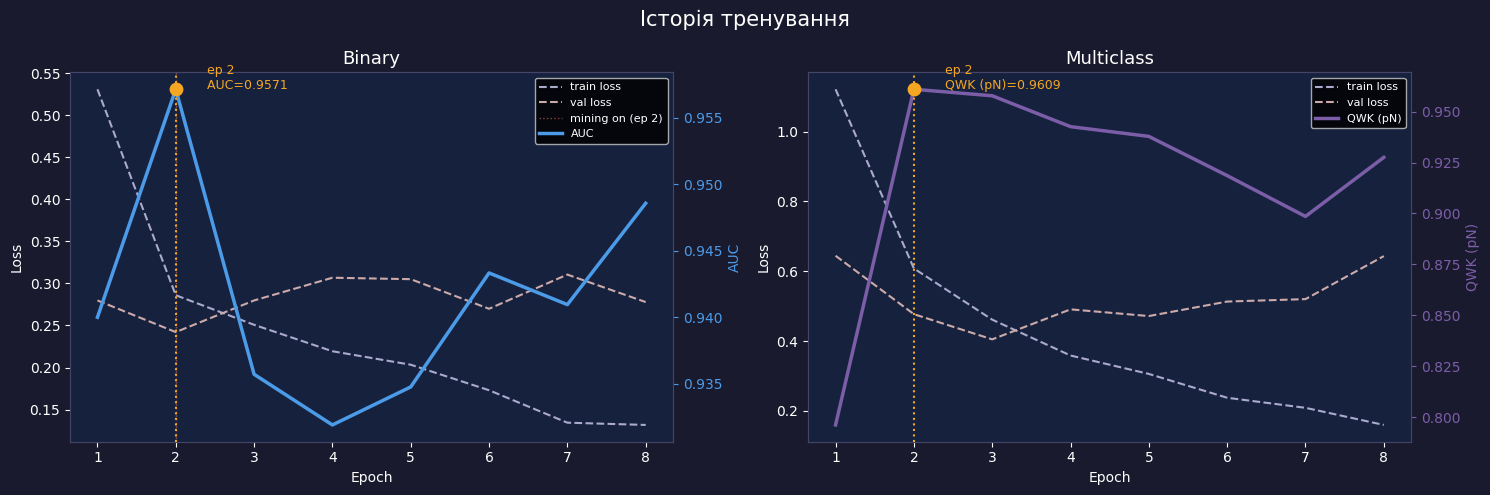


[A] Розподіл класів train/val …
  💾 збережено: /kaggle/working/A_class_distribution.png


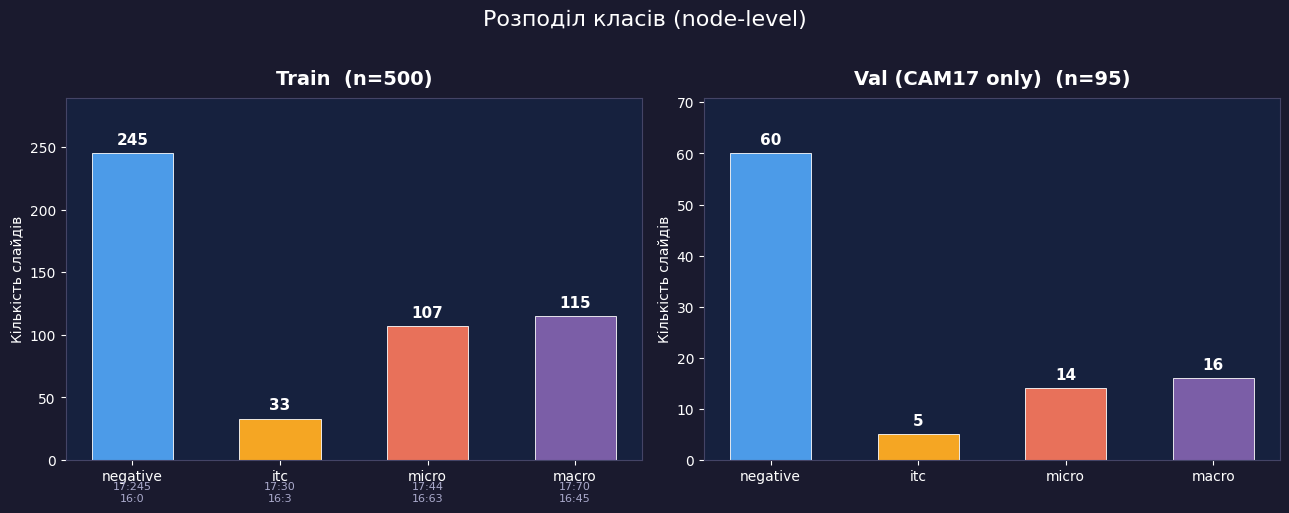


[B] Порівняння кількості патчів до/після parquet …
  💾 збережено: /kaggle/working/B_patch_comparison.png


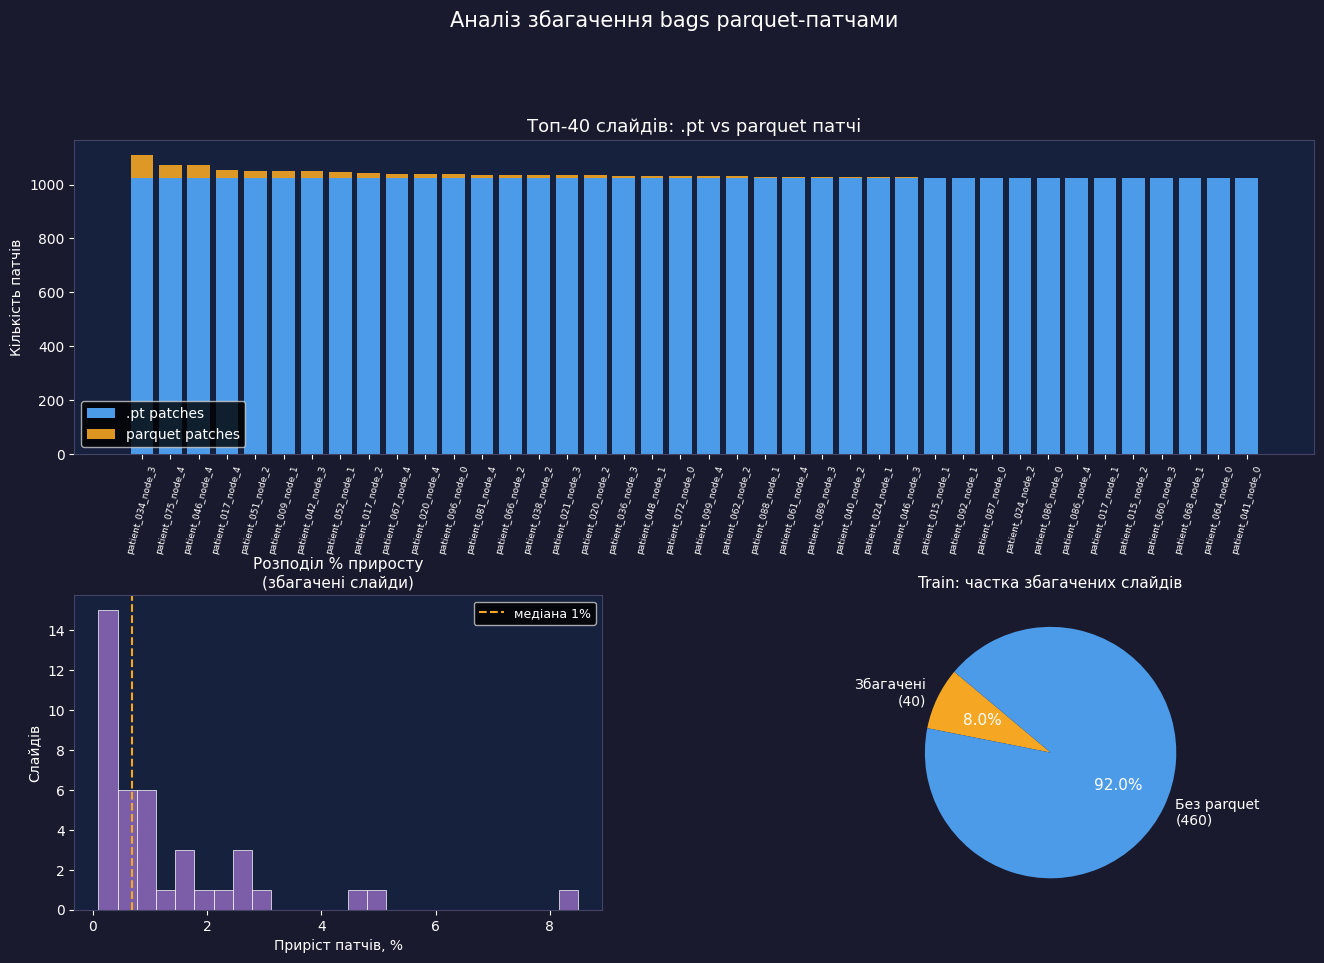


[C] Confusion matrices …
  💾 збережено: /kaggle/working/C_confusion_matrices.png


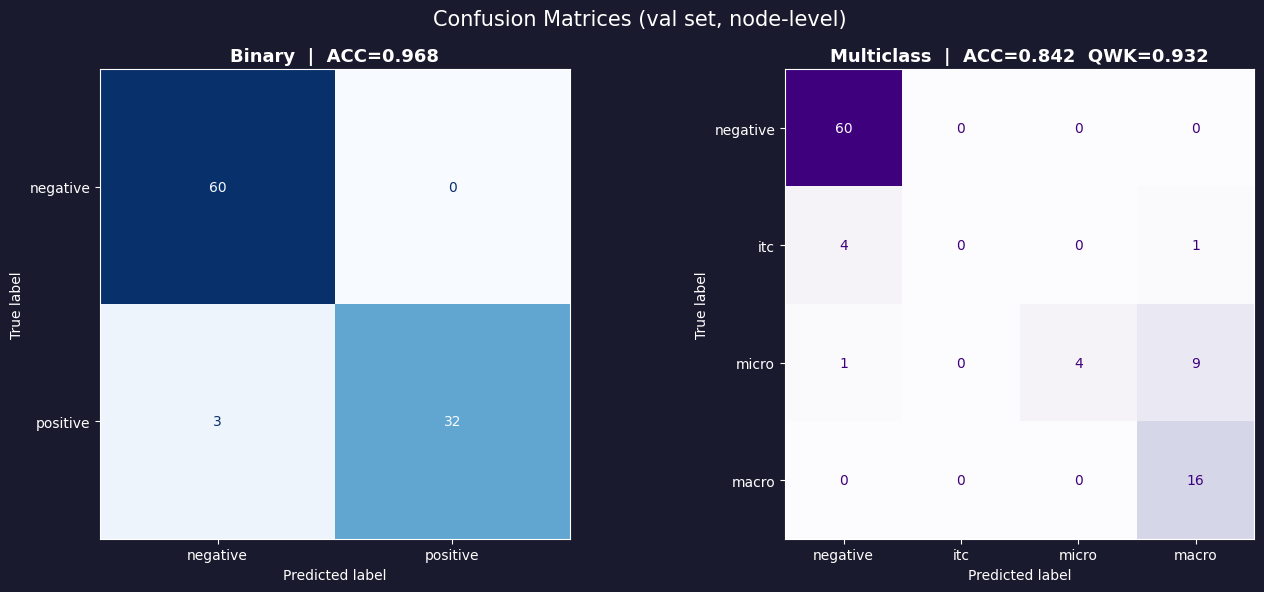


[D] UMAP ембедінгів …
  Проєктуємо 4800 патчів з 60 слайдів …


2026-04-19 17:55:54.722688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776621354.961170      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776621355.023065      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776621355.539615      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776621355.539685      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776621355.539688      23 computation_placer.cc:177] computation placer alr

  💾 збережено: /kaggle/working/D_embedding_umap.png


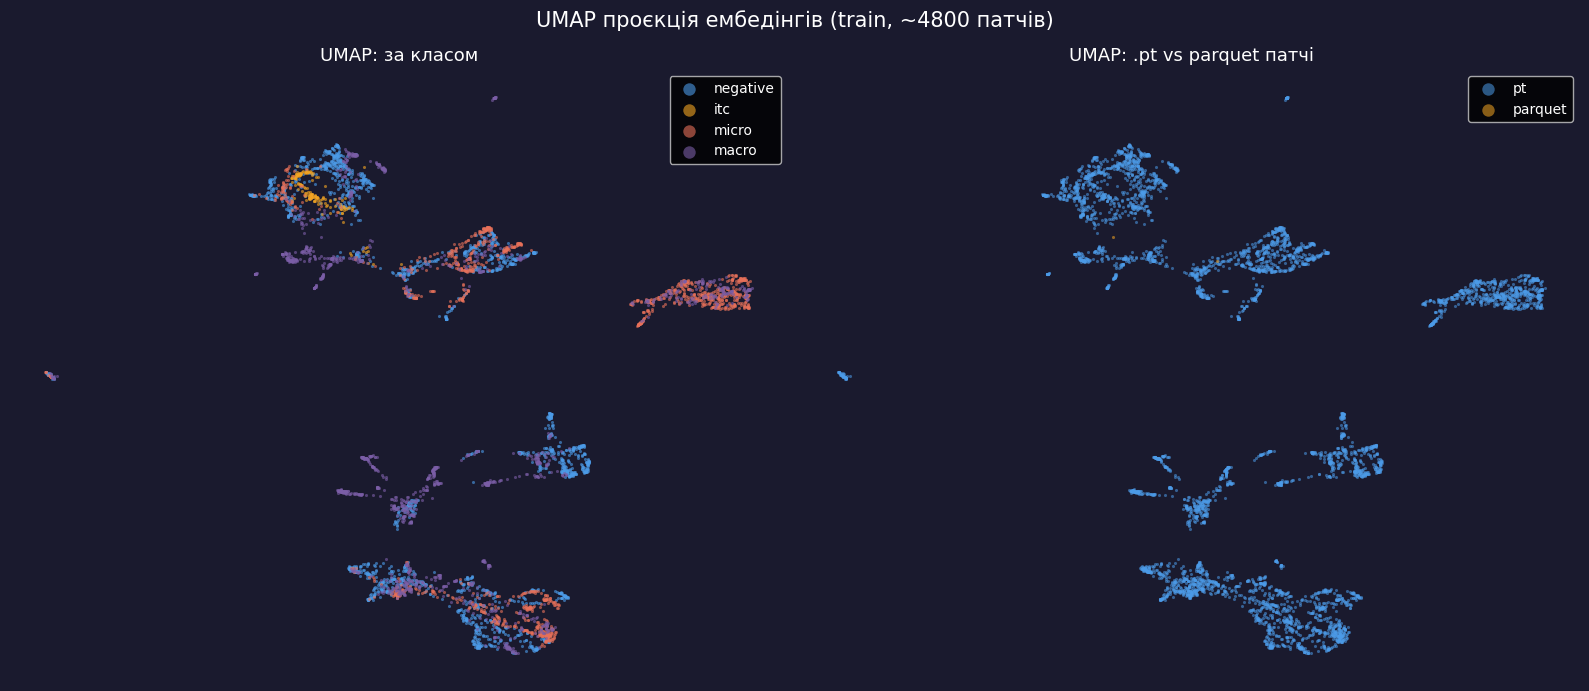


--- Attention: Binary model ---

[E] Attention heatmaps …
  💾 збережено: /kaggle/working/E_attn_c17__patient_073_node_3.png


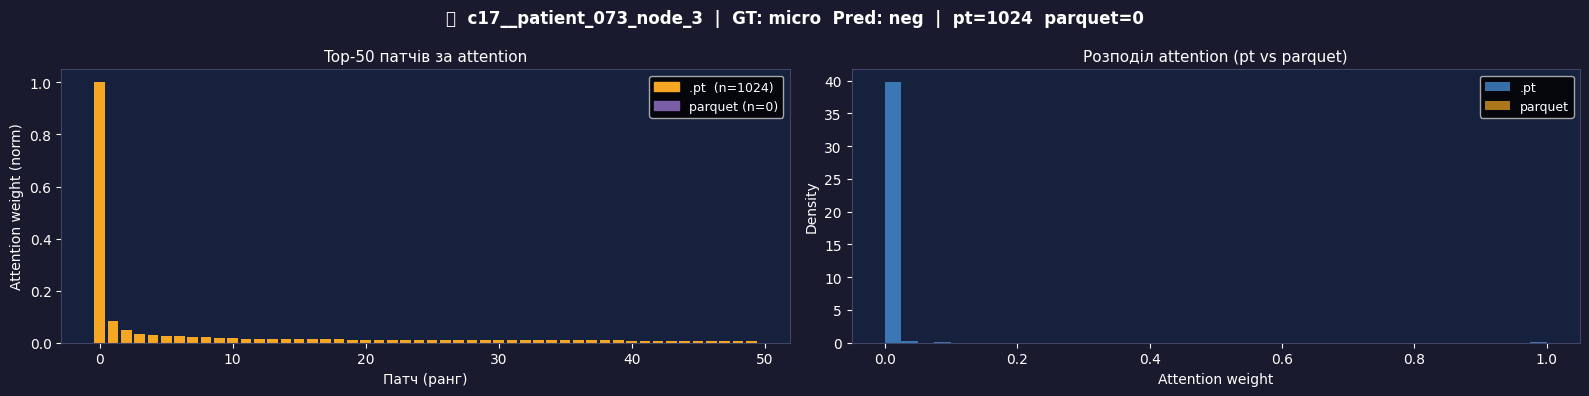

  💾 збережено: /kaggle/working/E_attn_c17__patient_018_node_2.png


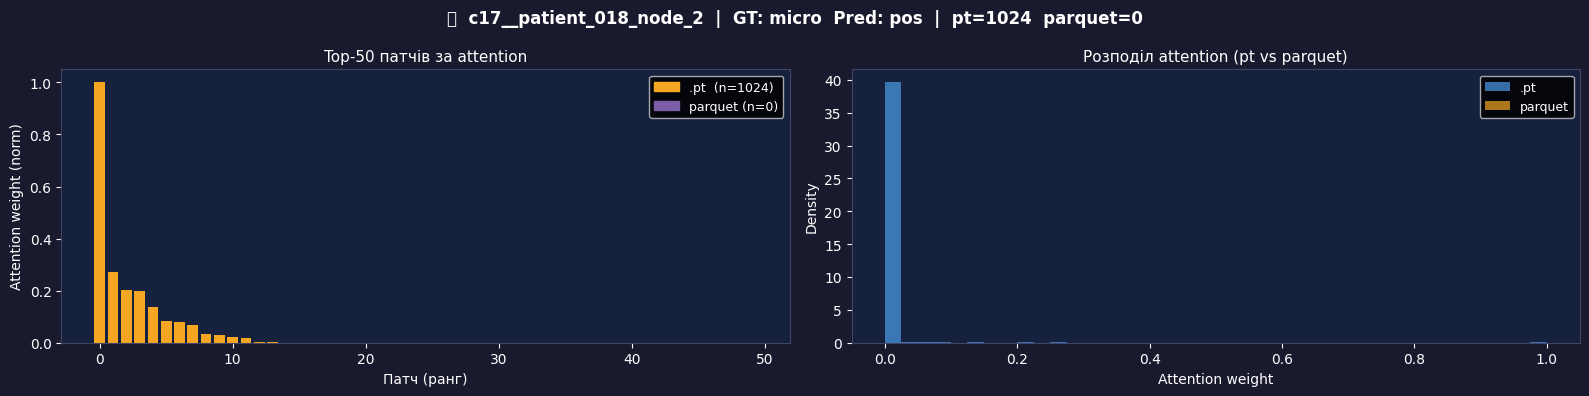

  💾 збережено: /kaggle/working/E_attn_c17__patient_076_node_2.png


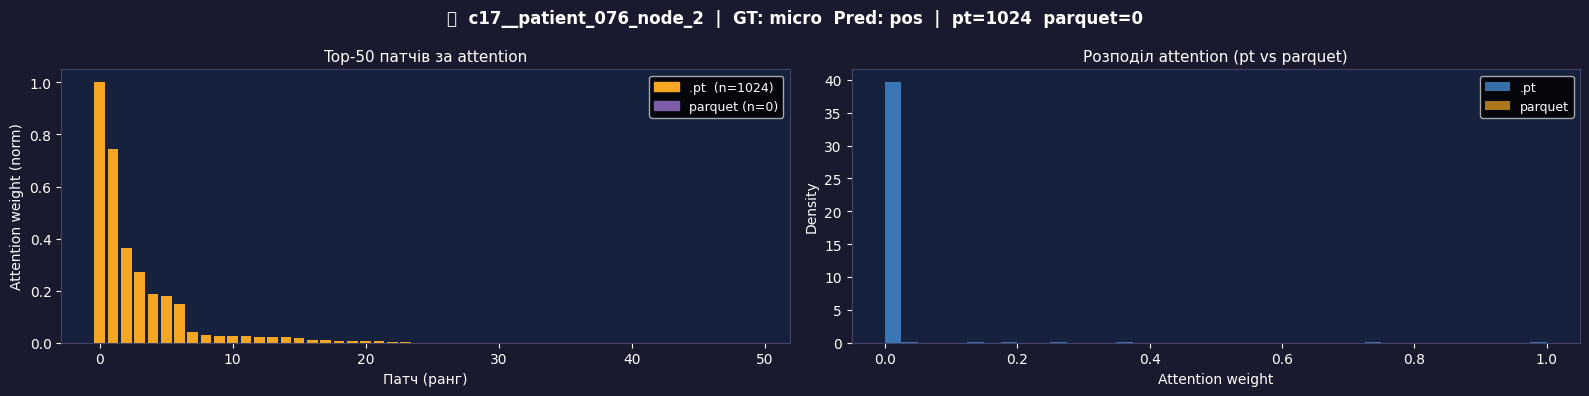

  💾 збережено: /kaggle/working/E_attn_c17__patient_076_node_3.png


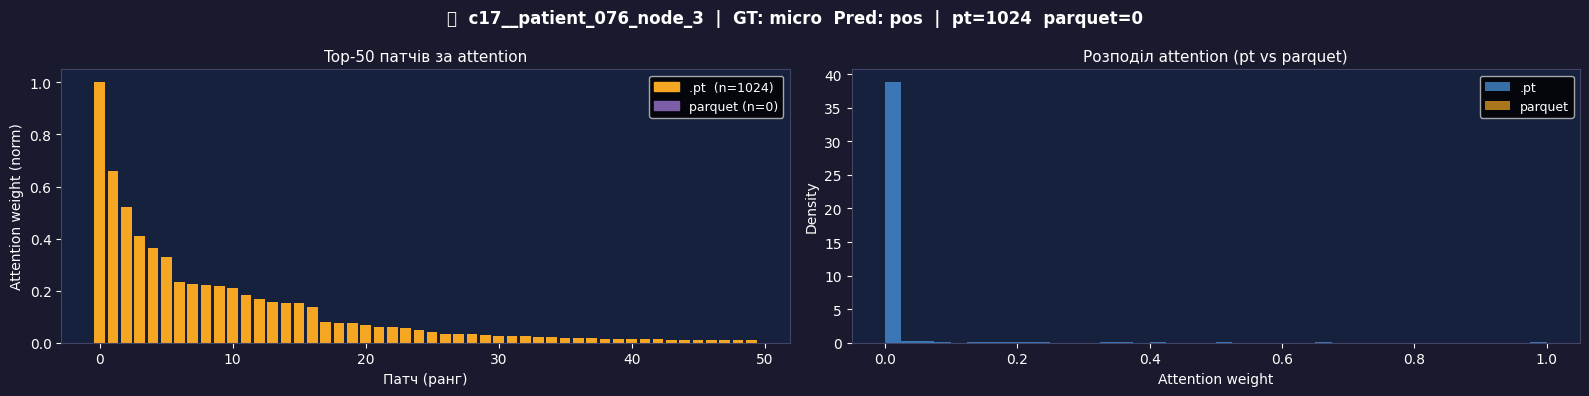

  💾 збережено: /kaggle/working/E_attn_c17__patient_000_node_0.png


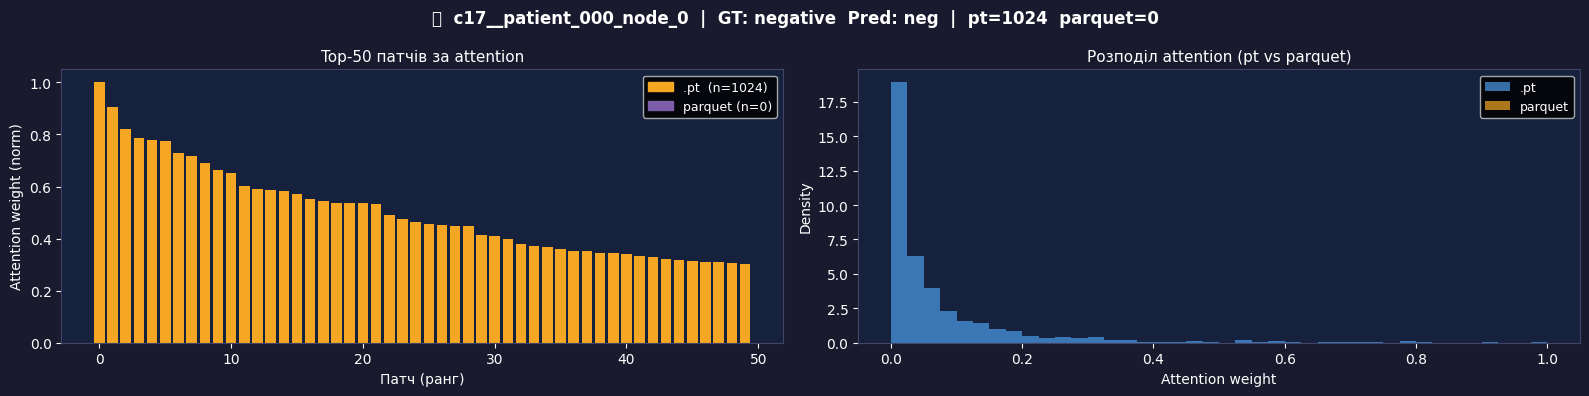

  💾 збережено: /kaggle/working/E_attn_c17__patient_022_node_1.png


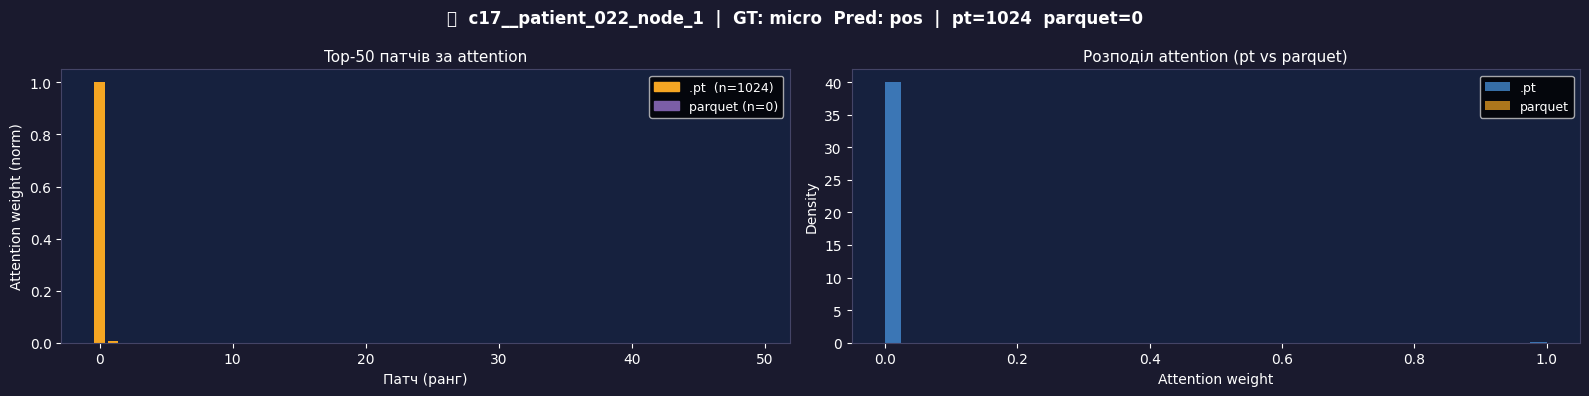


--- Attention: Multiclass model ---

[E] Attention heatmaps …
  💾 збережено: /kaggle/working/E_attn_c17__patient_073_node_3.png


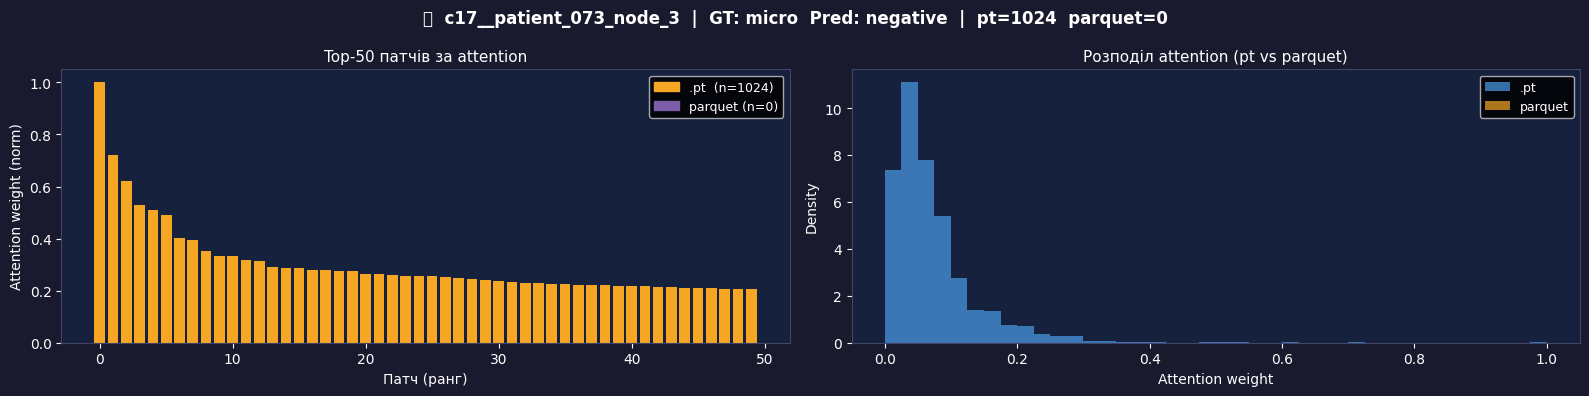

  💾 збережено: /kaggle/working/E_attn_c17__patient_018_node_2.png


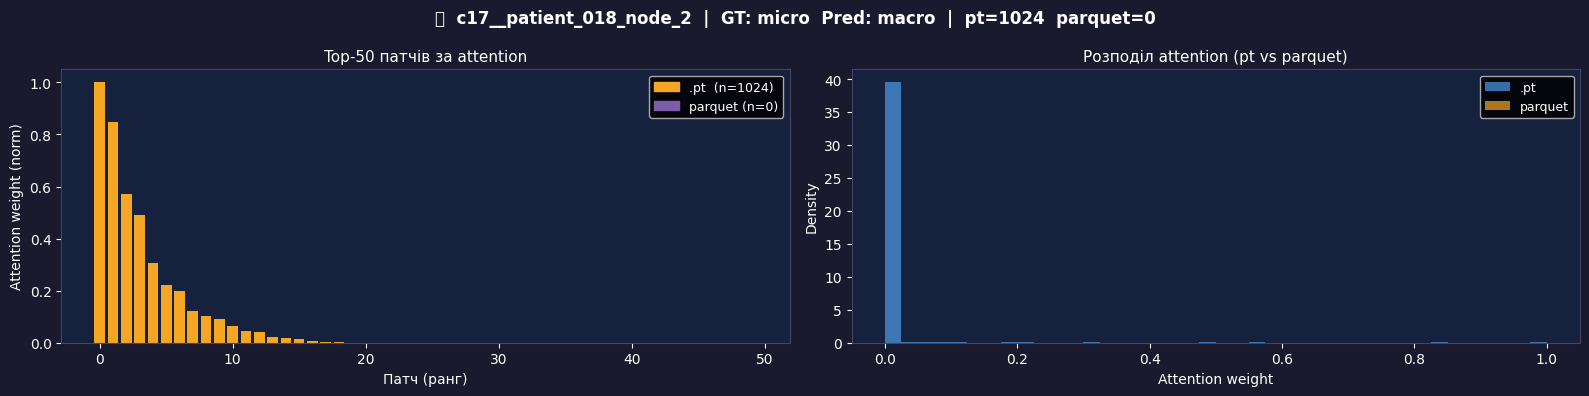

  💾 збережено: /kaggle/working/E_attn_c17__patient_076_node_2.png


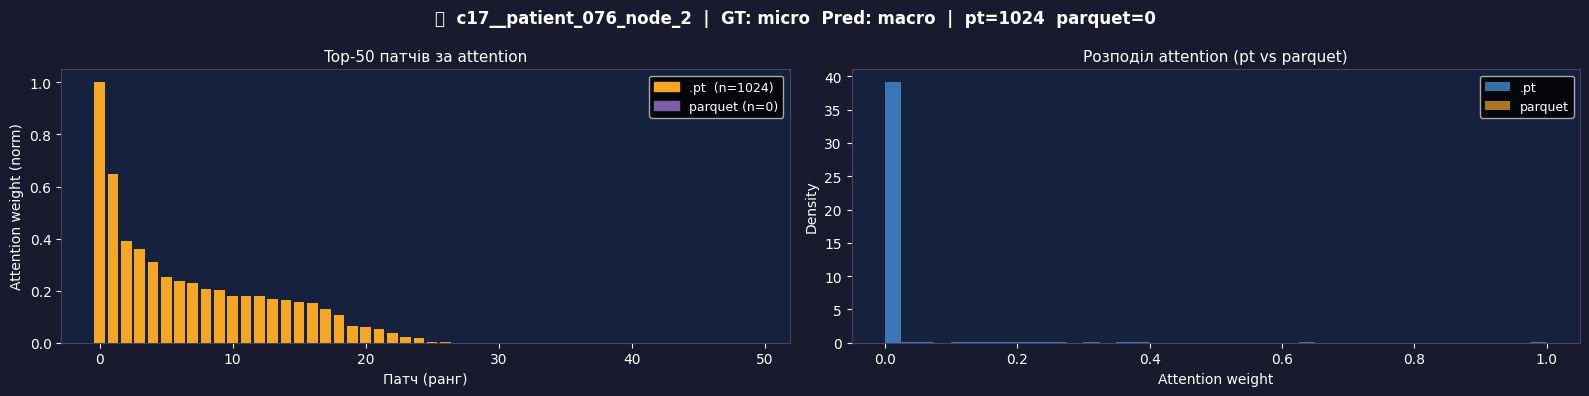

  💾 збережено: /kaggle/working/E_attn_c17__patient_076_node_3.png


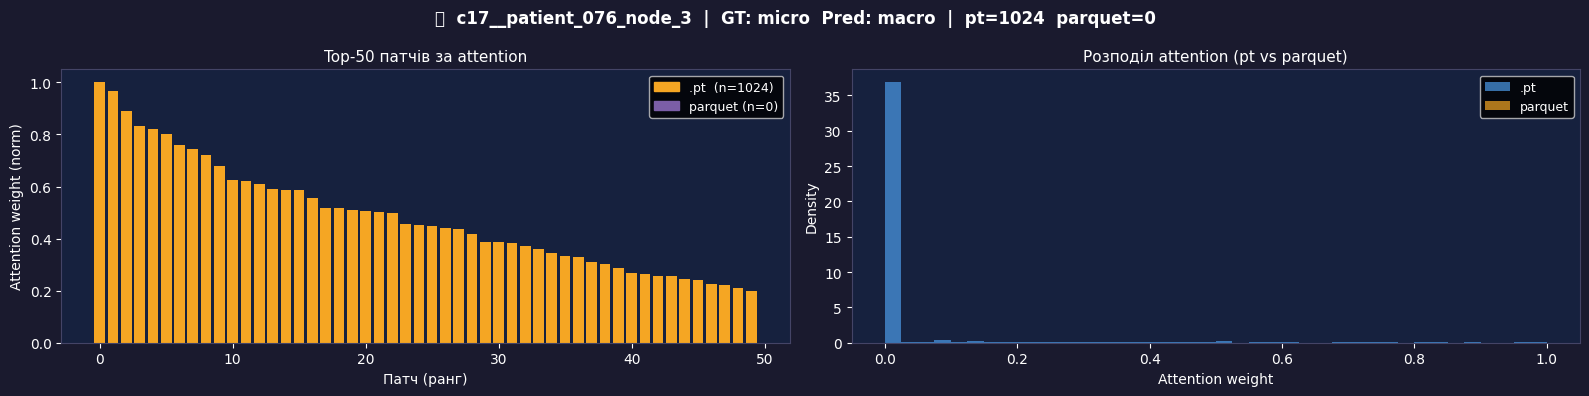

  💾 збережено: /kaggle/working/E_attn_c17__patient_000_node_0.png


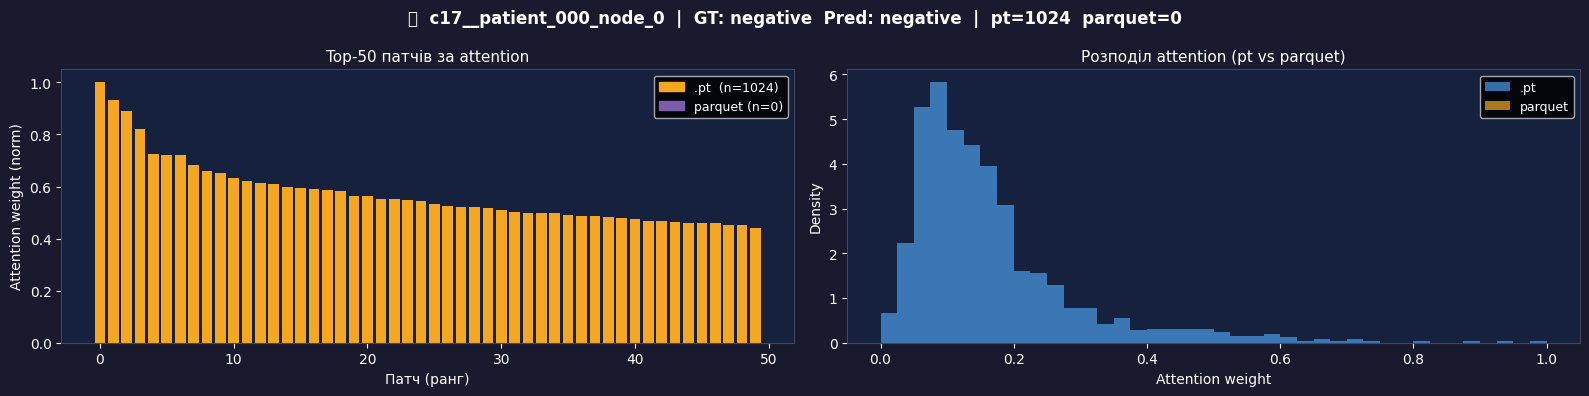

  💾 збережено: /kaggle/working/E_attn_c17__patient_022_node_1.png


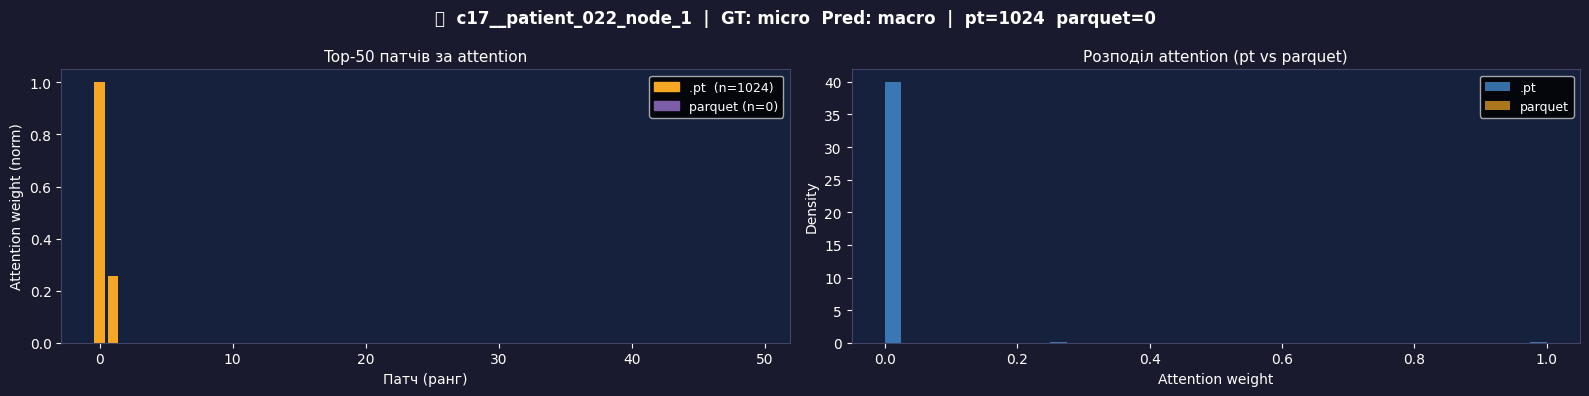

In [4]:
# ============================================================
# CELL 4: ВІЗУАЛІЗАЦІЯ
# Потребує: train_df, val_df, CFG, PARQUET_BAGS, D_EMB,
#           model_bin (Cell 2), model_mc (Cell 3),
#           val_df_bin, val_df_mc
#
# Блоки:
#   [A] Розподіл класів train/val
#   [B] Порівняння патчів до/після parquet
#   [C] Confusion matrix (binary + multiclass)
#   [D] UMAP/t-SNE ембедінгів
#   [E] Attention heatmap на WSI thumbnail
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.gridspec import GridSpec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Палітра ──────────────────────────────────────────────────
STAGE_COLORS  = {"negative": "#4C9BE8", "itc": "#F5A623", "micro": "#E8715A", "macro": "#7B5EA7"}
STAGE_ORDER   = ["negative", "itc", "micro", "macro"]
PN_LABELS     = ["pN0", "pN0(i+)", "pN1mi", "pN1", "pN2"]
BINARY_LABELS = ["negative", "positive"]

FIG_DPI   = 130
FIG_STYLE = "dark_background"
plt.style.use(FIG_STYLE)

# ── Helpers ───────────────────────────────────────────────────
def save_fig(fig, name: str, dpi: int = FIG_DPI):
    path = f"/kaggle/working/{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"  💾 збережено: {path}")

def load_emb(slide_uid: str) -> torch.Tensor:
    pt_path = os.path.join(CFG["emb_dir"], slide_uid + ".pt")
    data    = torch.load(pt_path, map_location="cpu")
    return data["features"].float()


# ══════════════════════════════════════════════════════════════
# [A] РОЗПОДІЛ КЛАСІВ TRAIN / VAL
# ══════════════════════════════════════════════════════════════
def plot_class_distribution():
    print("\n[A] Розподіл класів train/val …")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#1a1a2e")

    for ax, df, title in [
        (axes[0], train_df, "Train"),
        (axes[1], val_df,   "Val (CAM17 only)"),
    ]:
        ax.set_facecolor("#16213e")
        counts = df["stage"].value_counts().reindex(STAGE_ORDER, fill_value=0)
        bars   = ax.bar(
            counts.index,
            counts.values,
            color=[STAGE_COLORS[s] for s in counts.index],
            width=0.55,
            edgecolor="white",
            linewidth=0.6,
        )
        # підписи над стовпцями
        for bar, val in zip(bars, counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts.values) * 0.02,
                str(val),
                ha="center", va="bottom",
                color="white", fontsize=11, fontweight="bold",
            )
        # cam16 / cam17 split (тільки для train)
        if title == "Train" and "dataset" in df.columns:
            for i, stage in enumerate(STAGE_ORDER):
                sub = df[df["stage"] == stage]
                n17 = (sub["dataset"] == "cam17").sum()
                n16 = (sub["dataset"] == "cam16").sum()
                ax.text(
                    i, -max(counts.values) * 0.07,
                    f"17:{n17}\n16:{n16}",
                    ha="center", va="top",
                    color="#aaaacc", fontsize=8,
                )

        ax.set_title(f"{title}  (n={len(df)})", color="white", fontsize=14, fontweight="bold", pad=10)
        ax.set_ylabel("Кількість слайдів", color="white")
        ax.tick_params(colors="white")
        ax.spines[:].set_color("#444466")
        ax.set_ylim(0, max(counts.values) * 1.18)

    fig.suptitle("Розподіл класів (node-level)", color="white", fontsize=16, y=1.02)
    plt.tight_layout()
    save_fig(fig, "A_class_distribution")
    plt.show()


# ══════════════════════════════════════════════════════════════
# [B] ПОРІВНЯННЯ ПАТЧІВ ДО / ПІСЛЯ PARQUET
# ══════════════════════════════════════════════════════════════
def plot_patch_comparison():
    print("\n[B] Порівняння кількості патчів до/після parquet …")

    rows = []
    for uid in train_df["slide_uid"]:
        try:
            pt_n = load_emb(uid).shape[0]
        except Exception:
            continue
        pq_n = PARQUET_BAGS[uid].shape[0] if uid in PARQUET_BAGS else 0
        rows.append({
            "slide_uid": uid,
            "pt_patches": pt_n,
            "pq_patches": pq_n,
            "total":      pt_n + pq_n,
            "enriched":   pq_n > 0,
            "stage":      train_df.loc[train_df["slide_uid"] == uid, "stage"].iloc[0],
        })

    df_patch = pd.DataFrame(rows).sort_values("total", ascending=False).reset_index(drop=True)
    enriched = df_patch[df_patch["enriched"]]
    plain    = df_patch[~df_patch["enriched"]]

    fig = plt.figure(figsize=(16, 10), facecolor="#1a1a2e")
    gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── B1: горизонтальний stacked bar (топ-40 слайдів) ──────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.set_facecolor("#16213e")

    top = df_patch.head(min(40, len(df_patch)))
    x   = np.arange(len(top))

    ax1.bar(x, top["pt_patches"],  color="#4C9BE8", label=".pt patches",     width=0.8)
    ax1.bar(x, top["pq_patches"], bottom=top["pt_patches"],
            color="#F5A623", label="parquet patches", width=0.8, alpha=0.9)

    ax1.set_xticks(x)
    ax1.set_xticklabels(
        [u.replace("c17__","").replace("c16__","")[:18] for u in top["slide_uid"]],
        rotation=75, fontsize=6.5, color="white",
    )
    ax1.set_ylabel("Кількість патчів", color="white")
    ax1.set_title(f"Топ-{len(top)} слайдів: .pt vs parquet патчі", color="white", fontsize=13)
    ax1.tick_params(colors="white")
    ax1.spines[:].set_color("#444466")
    ax1.legend(fontsize=10)

    # ── B2: гістограма приросту (тільки збагачені) ───────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_facecolor("#16213e")
    if len(enriched):
        gain_pct = (enriched["pq_patches"] / enriched["pt_patches"] * 100).clip(0, 500)
        ax2.hist(gain_pct, bins=25, color="#7B5EA7", edgecolor="white", linewidth=0.5)
        ax2.axvline(gain_pct.median(), color="#F5A623", lw=1.5, linestyle="--",
                    label=f"медіана {gain_pct.median():.0f}%")
        ax2.set_xlabel("Приріст патчів, %", color="white")
        ax2.set_ylabel("Слайдів", color="white")
        ax2.set_title("Розподіл % приросту\n(збагачені слайди)", color="white", fontsize=11)
        ax2.tick_params(colors="white"); ax2.spines[:].set_color("#444466")
        ax2.legend(fontsize=9)
    else:
        ax2.text(0.5, 0.5, "Немає збагачених слайдів", ha="center", va="center",
                 color="white", transform=ax2.transAxes)

    # ── B3: pie – збагачені vs незбагачені ───────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_facecolor("#16213e")
    sizes  = [len(enriched), len(plain)]
    labels = [f"Збагачені\n({len(enriched)})", f"Без parquet\n({len(plain)})"]
    colors = ["#F5A623", "#4C9BE8"]
    wedges, texts, autotexts = ax3.pie(
        sizes, labels=labels, colors=colors,
        autopct="%1.1f%%", startangle=140,
        textprops={"color": "white", "fontsize": 10},
    )
    for at in autotexts:
        at.set_color("white"); at.set_fontsize(11)
    ax3.set_title("Train: частка збагачених слайдів", color="white", fontsize=11)

    fig.suptitle("Аналіз збагачення bags parquet-патчами", color="white", fontsize=15, y=1.01)
    save_fig(fig, "B_patch_comparison")
    plt.show()


# ══════════════════════════════════════════════════════════════
# [C] CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
def _get_binary_preds(model):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for uid, label in zip(val_df_bin["slide_uid"], val_df_bin["label"]):
            try:
                emb = load_emb(uid)
                if uid in PARQUET_BAGS and PARQUET_BAGS[uid].shape[1] == emb.shape[1]:
                    emb = torch.cat([emb, PARQUET_BAGS[uid]], dim=0)
                emb = emb.to(DEVICE)
                logit, prob, _, _ = model(emb)
                y_pred.append(int((prob.item() >= 0.5)))
                y_true.append(int(label))
            except Exception:
                continue
    return np.array(y_true), np.array(y_pred)


def _get_mc_preds(model):
    """Node-level predictions для multiclass."""
    STAGE2ID_ = {"negative": 0, "itc": 1, "micro": 2, "macro": 3}
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for _, row in val_df_mc.iterrows():
            try:
                emb = load_emb(row["slide_uid"])
                if row["slide_uid"] in PARQUET_BAGS and PARQUET_BAGS[row["slide_uid"]].shape[1] == emb.shape[1]:
                    emb = torch.cat([emb, PARQUET_BAGS[row["slide_uid"]]], dim=0)
                emb = emb.to(DEVICE)
                bag_logits, _, _ = model(emb)
                y_pred.append(int(torch.argmax(bag_logits, dim=1).item()))
                y_true.append(int(row["stage_id"]))
            except Exception:
                continue
    return np.array(y_true), np.array(y_pred)


def plot_confusion_matrices():
    print("\n[C] Confusion matrices …")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="#1a1a2e")

    # ── Binary ───────────────────────────────────────────────
    ax = axes[0]; ax.set_facecolor("#16213e")
    try:
        yt, yp = _get_binary_preds(model_bin)
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=BINARY_LABELS)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        acc = (yt == yp).mean()
        ax.set_title(f"Binary  |  ACC={acc:.3f}", color="white", fontsize=13, fontweight="bold")
    except Exception as e:
        ax.text(0.5, 0.5, f"Помилка:\n{e}", ha="center", va="center",
                color="white", transform=ax.transAxes)
    ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")

    # ── Multiclass ───────────────────────────────────────────
    ax = axes[1]; ax.set_facecolor("#16213e")
    try:
        yt, yp = _get_mc_preds(model_mc)
        cm = confusion_matrix(yt, yp, labels=[0, 1, 2, 3])
        disp = ConfusionMatrixDisplay(cm, display_labels=STAGE_ORDER)
        disp.plot(ax=ax, colorbar=False, cmap="Purples")
        acc = (yt == yp).mean()

        from sklearn.metrics import cohen_kappa_score
        kappa = cohen_kappa_score(yt, yp, weights="quadratic",
                                  labels=[0,1,2,3]) if len(np.unique(yt)) > 1 else float("nan")
        ax.set_title(f"Multiclass  |  ACC={acc:.3f}  QWK={kappa:.3f}",
                     color="white", fontsize=13, fontweight="bold")
    except Exception as e:
        ax.text(0.5, 0.5, f"Помилка:\n{e}", ha="center", va="center",
                color="white", transform=ax.transAxes)
    ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")

    fig.suptitle("Confusion Matrices (val set, node-level)", color="white", fontsize=15)
    plt.tight_layout()
    save_fig(fig, "C_confusion_matrices")
    plt.show()


# ══════════════════════════════════════════════════════════════
# [D] UMAP / t-SNE ембедінгів
# ══════════════════════════════════════════════════════════════
def plot_embedding_projection(
    method: str = "umap",   # "umap" | "tsne"
    max_slides: int = 60,
    patches_per_slide: int = 80,
):
    print(f"\n[D] {method.upper()} ембедінгів …")

    # Збираємо патчі
    rng     = np.random.RandomState(CFG["seed"])
    all_emb, all_labels, all_origins = [], [], []

    sample_uids = train_df["slide_uid"].tolist()
    rng.shuffle(sample_uids)
    sample_uids = sample_uids[:max_slides]

    for uid in sample_uids:
        try:
            emb = load_emb(uid)
        except Exception:
            continue
        if uid in PARQUET_BAGS and PARQUET_BAGS[uid].shape[1] == emb.shape[1]:
            pt_n  = emb.shape[0]
            extra = PARQUET_BAGS[uid]
            emb   = torch.cat([emb, extra], dim=0)
        else:
            pt_n = emb.shape[0]
            extra = None

        # семплюємо patches_per_slide патчів
        N = emb.shape[0]
        idx = rng.choice(N, min(patches_per_slide, N), replace=False)
        chosen = emb[idx].numpy()
        stage  = train_df.loc[train_df["slide_uid"] == uid, "stage"].iloc[0]

        all_emb.append(chosen)
        all_labels.extend([stage] * len(idx))
        # відмічаємо звідки патч: pt або parquet
        origins = ["parquet" if i >= pt_n else "pt" for i in idx]
        all_origins.extend(origins)

    if not all_emb:
        print("  Немає даних для проєкції")
        return

    X      = np.vstack(all_emb)
    labels = np.array(all_labels)
    origins = np.array(all_origins)
    print(f"  Проєктуємо {X.shape[0]} патчів з {len(all_emb)} слайдів …")

    # Редукція
    if method == "umap":
        try:
            import umap
            reducer = umap.UMAP(n_components=2, random_state=CFG["seed"],
                                n_neighbors=20, min_dist=0.1)
            Z = reducer.fit_transform(X)
        except ImportError:
            print("  umap-learn не встановлено → fallback to t-SNE")
            method = "tsne"
    if method == "tsne":
        from sklearn.manifold import TSNE
        Z = TSNE(n_components=2, random_state=CFG["seed"],
                 perplexity=min(40, X.shape[0]//4)).fit_transform(X)

    # Графік: ліво — за класом, право — pt vs parquet
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#1a1a2e")
    title_method = method.upper()

    # ── За класом ────────────────────────────────────────────
    ax = axes[0]; ax.set_facecolor("#0d0d1a")
    for stage in STAGE_ORDER:
        mask = labels == stage
        if mask.sum() == 0: continue
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=STAGE_COLORS[stage], label=stage,
                   s=5, alpha=0.6, linewidths=0)
    ax.set_title(f"{title_method}: за класом", color="white", fontsize=13)
    ax.legend(markerscale=4, fontsize=10)
    ax.axis("off")

    # ── Джерело патчів (pt vs parquet) ───────────────────────
    ax = axes[1]; ax.set_facecolor("#0d0d1a")
    src_colors = {"pt": "#4C9BE8", "parquet": "#F5A623"}
    for src, col in src_colors.items():
        mask = origins == src
        if mask.sum() == 0: continue
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=col, label=src,
                   s=5, alpha=0.55, linewidths=0)
    ax.set_title(f"{title_method}: .pt vs parquet патчі", color="white", fontsize=13)
    ax.legend(markerscale=4, fontsize=10)
    ax.axis("off")

    fig.suptitle(f"{title_method} проєкція ембедінгів (train, ~{X.shape[0]} патчів)",
                 color="white", fontsize=15)
    plt.tight_layout()
    save_fig(fig, f"D_embedding_{method}")
    plt.show()


# ══════════════════════════════════════════════════════════════
# [E] ATTENTION HEATMAP НА WSI THUMBNAIL
# ══════════════════════════════════════════════════════════════
def plot_attention_heatmaps(
    model,
    df: pd.DataFrame,
    n_slides: int = 6,
    patch_size_lvl0: int = 512,  # розмір патча на рівні 0
    alpha: float = 0.55,
):
    """
    Малює attention як heatmap поверх WSI thumbnail.

    Потребує колонку 'wsi_path' в df.
    Якщо wsi_path відсутній — показує тільки attention bar-chart по патчах.
    """
    print("\n[E] Attention heatmaps …")

    try:
        import openslide
        HAS_OPENSLIDE = True
    except ImportError:
        HAS_OPENSLIDE = False
        print("  openslide не знайдено → режим без WSI thumbnail")

    model.eval()
    rng = np.random.RandomState(CFG["seed"])
    sample_df = df.sample(min(n_slides, len(df)), random_state=CFG["seed"]).reset_index(drop=True)

    for _, row in sample_df.iterrows():
        uid     = row["slide_uid"]
        stage   = row.get("stage", "?")
        wsi_path = row.get("wsi_path", None)

        try:
            emb = load_emb(uid)
        except Exception as e:
            print(f"  ⚠️ {uid}: {e}"); continue

        # Збагачення parquet
        n_pt = emb.shape[0]
        if uid in PARQUET_BAGS and PARQUET_BAGS[uid].shape[1] == emb.shape[1]:
            emb = torch.cat([emb, PARQUET_BAGS[uid]], dim=0)

        emb_dev = emb.to(DEVICE)
        with torch.no_grad():
            out = model(emb_dev)

        # Підтримка і binary, і multiclass
        if len(out) == 4:
            # binary: bag_logit, bag_prob, inst_logit, attn_w
            attn_w = out[3].detach().cpu().float().numpy()
            pred_label = "pos" if out[1].item() >= 0.5 else "neg"
        else:
            # multiclass: bag_logits, inst_logits, attn_w
            attn_w = out[2].detach().cpu().float().numpy()
            pred_id = int(torch.argmax(out[0], dim=1).item())
            pred_label = STAGE_ORDER[pred_id]

        attn_w = (attn_w - attn_w.min()) / (attn_w.max() - attn_w.min() + 1e-12)

        # ── Варіант 1: є WSI + coords ─────────────────────────
        has_coords = False
        if HAS_OPENSLIDE and wsi_path and os.path.exists(str(wsi_path)):
            try:
                pt_data = torch.load(
                    os.path.join(CFG["emb_dir"], uid + ".pt"), map_location="cpu"
                )
                coords = pt_data.get("coords", None)  # [N, 2] у пікселях lvl0

                if coords is not None:
                    has_coords = True
                    coords = coords.numpy()  # [N_pt, 2]

                    # Parquet патчі: якщо є coords в PARQUET_BAGS — append, інакше — ігноруємо
                    # (зазвичай parquet не має coords → атенція по них не малюється на thumbnail)
                    n_with_coords = min(len(coords), n_pt)

                    slide = openslide.OpenSlide(str(wsi_path))
                    W, H  = slide.dimensions
                    THUMB = 1536
                    scale = max(W, H) / THUMB
                    tw, th = max(1, int(W / scale)), max(1, int(H / scale))
                    thumb  = np.array(slide.get_thumbnail((tw, th)).convert("RGB"))
                    slide.close()

                    # Будуємо heatmap-сітку
                    heatmap = np.zeros((th, tw), dtype=np.float32)
                    count   = np.zeros((th, tw), dtype=np.float32)
                    ps      = max(1, int(patch_size_lvl0 / scale))

                    for i, (cx, cy) in enumerate(coords[:n_with_coords]):
                        tx = max(0, min(int(cx / scale), tw - ps))
                        ty = max(0, min(int(cy / scale), th - ps))
                        heatmap[ty:ty+ps, tx:tx+ps] += attn_w[i]
                        count  [ty:ty+ps, tx:tx+ps] += 1.0

                    count   = np.maximum(count, 1e-12)
                    heatmap = heatmap / count
                    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-12)

                    cmap_heat = matplotlib.colormaps.get_cmap("inferno")
                    heat_rgb  = (cmap_heat(heatmap)[..., :3] * 255).astype(np.uint8)

                    composite = (
                        (1 - alpha) * thumb.astype(np.float32) +
                        alpha       * heat_rgb.astype(np.float32)
                    ).clip(0, 255).astype(np.uint8)

                    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#1a1a2e")

                    axes[0].imshow(thumb)
                    axes[0].set_title("WSI thumbnail", color="white", fontsize=11)
                    axes[0].axis("off")

                    axes[1].imshow(composite)
                    axes[1].set_title("Attention heatmap overlay", color="white", fontsize=11)
                    axes[1].axis("off")

                    im = axes[2].imshow(heatmap, cmap="inferno", vmin=0, vmax=1)
                    axes[2].set_title("Heatmap (чиста)", color="white", fontsize=11)
                    axes[2].axis("off")
                    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

                    correct = "✅" if stage == pred_label or (stage != "negative") == (pred_label != "neg") else "❌"
                    fig.suptitle(
                        f"{correct}  {uid}\nGT: {stage}  |  Pred: {pred_label}  "
                        f"|  pt={n_pt}  parquet={emb.shape[0]-n_pt}",
                        color="white", fontsize=13, fontweight="bold",
                    )
                    plt.tight_layout()
                    save_fig(fig, f"E_attn_{uid[:40]}")
                    plt.show()
                    continue

            except Exception as e:
                print(f"  ⚠️ WSI heatmap для {uid} не вдалося: {e}")

        # ── Варіант 2: немає WSI або coords → bar chart ───────
        fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor="#1a1a2e")

        # Top-50 патчів
        top_k = min(50, len(attn_w))
        top_idx = np.argsort(-attn_w)[:top_k]
        top_val = attn_w[top_idx]
        colors  = ["#F5A623" if i < n_pt else "#7B5EA7" for i in top_idx]

        ax = axes[0]; ax.set_facecolor("#16213e")
        ax.bar(np.arange(top_k), top_val, color=colors, width=0.8)
        ax.set_xlabel("Патч (ранг)", color="white")
        ax.set_ylabel("Attention weight (norm)", color="white")
        ax.set_title(f"Top-{top_k} патчів за attention", color="white", fontsize=11)
        ax.tick_params(colors="white"); ax.spines[:].set_color("#444466")

        pt_patch  = mpatches.Patch(color="#F5A623", label=f".pt  (n={n_pt})")
        pq_patch  = mpatches.Patch(color="#7B5EA7", label=f"parquet (n={emb.shape[0]-n_pt})")
        ax.legend(handles=[pt_patch, pq_patch], fontsize=9)

        # Гістограма всіх weights
        ax = axes[1]; ax.set_facecolor("#16213e")
        ax.hist(attn_w[:n_pt],         bins=40, color="#4C9BE8", alpha=0.7, label=".pt",     density=True)
        ax.hist(attn_w[n_pt:],         bins=40, color="#F5A623", alpha=0.7, label="parquet", density=True)
        ax.set_xlabel("Attention weight", color="white")
        ax.set_ylabel("Density", color="white")
        ax.set_title("Розподіл attention (pt vs parquet)", color="white", fontsize=11)
        ax.tick_params(colors="white"); ax.spines[:].set_color("#444466")
        ax.legend(fontsize=9)

        correct = "✅" if stage == pred_label else "❌"
        fig.suptitle(
            f"{correct}  {uid}  |  GT: {stage}  Pred: {pred_label}  "
            f"|  pt={n_pt}  parquet={emb.shape[0]-n_pt}",
            color="white", fontsize=12, fontweight="bold",
        )
        plt.tight_layout()
        save_fig(fig, f"E_attn_{uid[:40]}")
        plt.show()


# ══════════════════════════════════════════════════════════════
# RUN ALL
# ══════════════════════════════════════════════════════════════

def restore_best_models():
    """
    Завантажує best_state з Cell 2/3 (збережено в пам'яті як dict).
    Якщо best_state недоступний — завантажує з .pt файлу на диску.
    Виводить епоху і QWK/AUC найкращого чекпоінту.
    """
    # ── Binary ───────────────────────────────────────────────
    try:
        if "best_state_bin" in globals() and best_state_bin is not None:
            model_bin.load_state_dict(best_state_bin)
            best_ep_bin = max(HIST_BIN, key=lambda r: r["val_auc"])
            print(f"✅ Binary model: best epoch={best_ep_bin['epoch']}  "
                  f"AUC={best_ep_bin['val_auc']:.4f}  "
                  f"F1={best_ep_bin['f1']:.4f}")
        else:
            # fallback: з файлу
            ckpt = torch.load("best_mil_binary.pt", map_location="cpu")
            model_bin.load_state_dict(ckpt)
            print("✅ Binary model: завантажено з best_mil_binary.pt")
    except Exception as e:
        print(f"⚠️  Binary model: не вдалося відновити best_state — {e}")
        print("   Використовується поточний стан моделі")

    # ── Multiclass ───────────────────────────────────────────
    try:
        if "best_state_mc" in globals() and best_state_mc is not None:
            model_mc.load_state_dict(best_state_mc)
            best_ep_mc = max(HIST_MC, key=lambda r: r["pn_qwk"])
            print(f"✅ Multiclass model: best epoch={best_ep_mc['epoch']}  "
                  f"QWK={best_ep_mc['pn_qwk']:.4f}  "
                  f"node_acc={best_ep_mc['node_acc']:.4f}")
        else:
            ckpt = torch.load("best_mil_pn.pt", map_location="cpu")
            model_mc.load_state_dict(ckpt)
            print("✅ Multiclass model: завантажено з best_mil_pn.pt")
    except Exception as e:
        print(f"⚠️  Multiclass model: не вдалося відновити best_state — {e}")
        print("   Використовується поточний стан моделі")

    model_bin.eval()
    model_mc.eval()


def plot_training_history():
    """Графік лосу і метрик по епохах з маркером найкращої епохи."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor="#1a1a2e")

    for ax, hist, metric_key, metric_label, title, color in [
        (axes[0], HIST_BIN, "val_auc", "AUC",     "Binary",      "#4C9BE8"),
        (axes[1], HIST_MC,  "pn_qwk",  "QWK (pN)", "Multiclass", "#7B5EA7"),
    ]:
        if not hist:
            ax.text(0.5, 0.5, "Немає даних історії", ha="center", va="center", color="white")
            continue
            
        ax.set_facecolor("#16213e")
        df_h = pd.DataFrame(hist)

        epochs      = df_h["epoch"].values
        train_loss  = df_h["train_loss"].values
        val_loss    = df_h["val_loss"].values
        metric_vals = df_h[metric_key].values

        ax2 = ax.twinx()
        ax.plot(epochs, train_loss, color="#aaaacc", lw=1.5,
                linestyle="--", label="train loss")
        ax.plot(epochs, val_loss,   color="#ccaaaa", lw=1.5,
                linestyle="--", label="val loss")
        ax2.plot(epochs, metric_vals, color=color, lw=2.5, label=metric_label)

        # Маркер найкращої епохи
        best_idx = int(np.argmax(metric_vals))
        best_ep  = epochs[best_idx]
        best_val = metric_vals[best_idx]

        ax2.axvline(best_ep, color="#F5A623", lw=1.5, linestyle=":")
        ax2.scatter([best_ep], [best_val], color="#F5A623", s=80, zorder=5)
        ax2.annotate(
            f"  ep {best_ep}\n  {metric_label}={best_val:.4f}",
            xy=(best_ep, best_val),
            color="#F5A623", fontsize=9,
            xytext=(best_ep + 0.3, best_val),
        )

        # --- ВИПРАВЛЕННЯ ТУТ: Перевірка наявності колонки 'mining' ---
        if "mining" in df_h.columns:
            mining_rows = df_h[df_h["mining"] == True]
            if len(mining_rows):
                first_mining = mining_rows["epoch"].iloc[0]
                ax.axvline(first_mining, color="#E8715A", lw=1, linestyle=":",
                           alpha=0.6, label=f"mining on (ep {first_mining})")
        # -----------------------------------------------------------

        ax.set_xlabel("Epoch", color="white")
        ax.set_ylabel("Loss", color="white")
        ax2.set_ylabel(metric_label, color=color)
        ax.set_title(title, color="white", fontsize=13)
        ax.tick_params(colors="white")
        ax2.tick_params(colors=color)
        ax.spines[:].set_color("#444466")
        ax2.spines[:].set_color("#444466")

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

    fig.suptitle("Історія тренування", color="white", fontsize=15)
    plt.tight_layout()
    save_fig(fig, "0_training_history")
    plt.show()


if __name__ == "__main__" or True:

    # ✅ Відновлюємо best model weights ПЕРЕД будь-якою візуалізацією
    restore_best_models()

    # [0] Графік тренування з маркером best epoch
    plot_training_history()

    # [A] Розподіл класів
    plot_class_distribution()

    # [B] Патчі до/після parquet
    plot_patch_comparison()

    # [C] Confusion matrices
    # ⚠️ val_df_bin і val_df_mc мають бути доступні з Cell 2/3
    plot_confusion_matrices()

    # [D] UMAP або t-SNE
    # Якщо є umap-learn → umap, інакше автоматично t-SNE
    plot_embedding_projection(method="umap", max_slides=60, patches_per_slide=80)

    # [E] Attention heatmaps
    # Бінарна модель (6 слайдів з val_df_bin)
    print("\n--- Attention: Binary model ---")
    plot_attention_heatmaps(model_bin, val_df_bin, n_slides=6)

    # Мультикласова модель (6 слайдів з val_df_mc)
    print("\n--- Attention: Multiclass model ---")
    plot_attention_heatmaps(model_mc, val_df_mc, n_slides=6)